In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 162.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 50.6 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from google.colab import drive

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
# Montar o Google Drive
drive.mount('/content/drive')

# Navegar até o diretório que contém o arquivo .npz
os.chdir('/content/drive/My Drive/0 - Doutorado/09.PCS5022 - Redes Neurais e Deep Learning/Scripts Colab/Paper')



Mounted at /content/drive


In [ ]:
# Ler o arquivo Excel
df_accepted = pd.read_csv("0.accepted_2007_to_2018Q4.csv")

print(df_accepted.shape)

/tmp/ipykernel_10521/1764951457.py:2: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df_accepted = pd.read_csv("0.accepted_2007_to_2018Q4.csv")


(2260701, 151)


In [ ]:
df_accepted.issue_d.head(50)

,issue_d
0,Dec-2015
1,Dec-2015
2,Dec-2015
3,Dec-2015
4,Dec-2015
5,Dec-2015
6,Dec-2015
7,Dec-2015
8,Dec-2015
9,Dec-2015


In [ ]:
df_accepted.head(50)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
6,68476668,NaN,20000.0,20000.0,20000.0,36 months,9.17,637.58,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
7,67275481,NaN,20000.0,20000.0,20000.0,36 months,8.49,631.26,B,B1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
8,68466926,NaN,10000.0,10000.0,10000.0,36 months,6.49,306.45,A,A2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9,68616873,NaN,8000.0,8000.0,8000.0,36 months,11.48,263.74,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
non_numeric_columns = df_accepted.select_dtypes(include=['object']).columns
print(non_numeric_columns)

Index(['id', 'term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code',
       'addr_state', 'earliest_cr_line', 'initial_list_status', 'last_pymnt_d',
       'next_pymnt_d', 'last_credit_pull_d', 'application_type',
       'verification_status_joint', 'sec_app_earliest_cr_line',
       'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
       'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date',
       'hardship_loan_status', 'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date'],
      dtype='object')


In [ ]:
df_accepted.loan_status.value_counts()

,count
loan_status,
Fully Paid,1076751
Current,878317
Charged Off,268559
Late (31-120 days),21467
In Grace Period,8436
Late (16-30 days),4349
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,40


In [ ]:
df_accepted = df_accepted[df_accepted.loan_status.isin(['Fully Paid', 'Charged Off'])]

print(df_accepted.shape)

(1345310, 151)


<Axes: xlabel='loan_status', ylabel='count'>

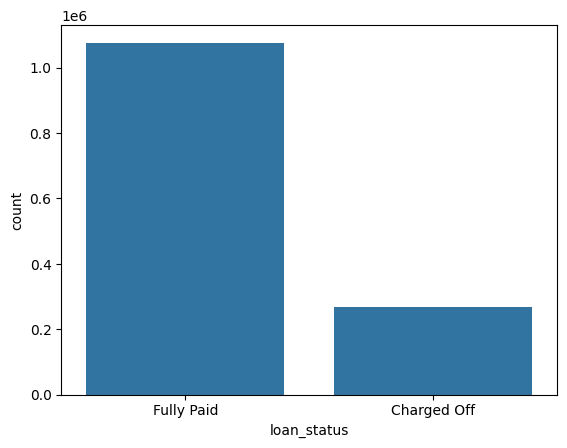

In [ ]:
sns.countplot(x="loan_status", data=df_accepted)

In [ ]:
df_accepted.isnull().sum().sort_values(ascending=False)

,0
member_id,1345310
next_pymnt_d,1345310
orig_projected_additional_accrued_interest,1341551
hardship_payoff_balance_amount,1339556
hardship_last_payment_amount,1339556
...,...
fico_range_high,0
fico_range_low,0
hardship_flag,0
disbursement_method,0


In [ ]:
df_accepted.isnull().sum().sort_values(ascending=False).head(50)

,0
member_id,1345310
next_pymnt_d,1345310
orig_projected_additional_accrued_interest,1341551
hardship_payoff_balance_amount,1339556
hardship_last_payment_amount,1339556
hardship_reason,1339556
hardship_type,1339556
hardship_status,1339556
hardship_amount,1339556
deferral_term,1339556


In [ ]:
print(df_accepted.columns)

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)


In [ ]:
cols_to_drop = df_accepted.isnull().sum().sort_values(ascending=False).head(50).index
df_accepted = df_accepted.drop(columns=cols_to_drop)
df_accepted.shape

(1345310, 101)

In [ ]:
df_accepted.isnull().sum().sort_values(ascending=False).head(50)

,0
open_act_il,807712
open_rv_24m,807712
max_bal_bc,807712
inq_fi,807712
total_bal_il,807712
open_rv_12m,807712
open_il_12m,807712
mths_since_last_delinq,678743
mths_since_recent_inq,174071
num_tl_120dpd_2m,117401


In [ ]:
cols_to_drop = df_accepted.isnull().sum().sort_values(ascending=False).head(45).index
df_accepted = df_accepted.drop(columns=cols_to_drop)
df_accepted.shape

(1345310, 56)

In [ ]:
nulls = df_accepted.isnull().sum().sort_values(ascending=False)
nulls_percentage = (nulls/df_accepted.shape[0]*100)
nulls_percentage.head(15)

,0
last_pymnt_d,0.171931
revol_util,0.063703
pub_rec_bankruptcies,0.051810
dti,0.027800
chargeoff_within_12_mths,0.004163
collections_12_mths_ex_med,0.004163
last_credit_pull_d,0.004088
tax_liens,0.002899
inq_last_6mths,0.000074
zip_code,0.000074


In [ ]:
df_accepted = df_accepted.dropna()
df_accepted.shape

(1341026, 56)

In [ ]:
df_accepted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1341026 entries, 0 to 2260697
Data columns (total 56 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   id                          1341026 non-null  object 
 1   loan_amnt                   1341026 non-null  float64
 2   funded_amnt                 1341026 non-null  float64
 3   funded_amnt_inv             1341026 non-null  float64
 4   term                        1341026 non-null  object 
 5   int_rate                    1341026 non-null  float64
 6   installment                 1341026 non-null  float64
 7   grade                       1341026 non-null  object 
 8   sub_grade                   1341026 non-null  object 
 9   home_ownership              1341026 non-null  object 
 10  annual_inc                  1341026 non-null  float64
 11  verification_status         1341026 non-null  object 
 12  issue_d                     1341026 non-null  object 
 13  lo

<Axes: xlabel='loan_amnt', ylabel='Count'>

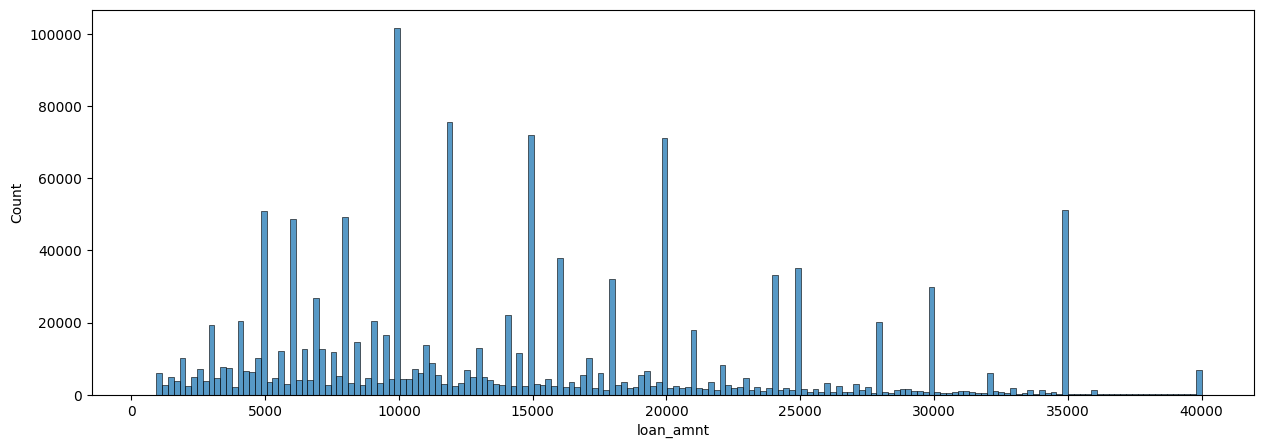

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df_accepted.loan_amnt, kde=False)

In [ ]:
print(df_accepted.columns)

Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url',
       'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'fico_range_low', 'fico_range_high',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv',
       'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d',
       'last_fico_range_high', 'last_fico_range_low',
       'collections_12_mths_ex_med', 'policy_code', 'application_type',
       'acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt',
       'pub_rec_bankruptcies', 'tax_liens', 'hardship_flag',
       'disbursement_me

In [ ]:
# Verificar se há strings em colunas que deveriam ser numéricas
for col in df_accepted.columns:
    if df_accepted[col].dtype == 'object':  # Colunas de tipo 'object' podem conter strings
        unique_values = df_accepted[col].unique()
        print(f"Valores únicos na coluna '{col}': {unique_values[:10]}")  # Exibe os 10 primeiros valores únicos


Valores únicos na coluna 'id': [68407277 68355089 68341763 68476807 68426831 68476668 67275481 68466926
 68616873 68338832]
Valores únicos na coluna 'term': [' 36 months' ' 60 months']
Valores únicos na coluna 'grade': ['C' 'B' 'F' 'A' 'E' 'D' 'G']
Valores únicos na coluna 'sub_grade': ['C4' 'C1' 'B4' 'F1' 'C3' 'B2' 'B1' 'A2' 'B5' 'C2']
Valores únicos na coluna 'home_ownership': ['MORTGAGE' 'RENT' 'OWN' 'ANY' 'NONE' 'OTHER']
Valores únicos na coluna 'verification_status': ['Not Verified' 'Source Verified' 'Verified']
Valores únicos na coluna 'issue_d': ['Dec-2015' 'Nov-2015' 'Oct-2015' 'Sep-2015' 'Aug-2015' 'Jul-2015'
 'Jun-2015' 'May-2015' 'Apr-2015' 'Mar-2015']
Valores únicos na coluna 'loan_status': ['Fully Paid' 'Charged Off']
Valores únicos na coluna 'pymnt_plan': ['n']
Valores únicos na coluna 'url': ['https://lendingclub.com/browse/loanDetail.action?loan_id=68407277'
 'https://lendingclub.com/browse/loanDetail.action?loan_id=68355089'
 'https://lendingclub.com/browse/loanDetail.

<Axes: >

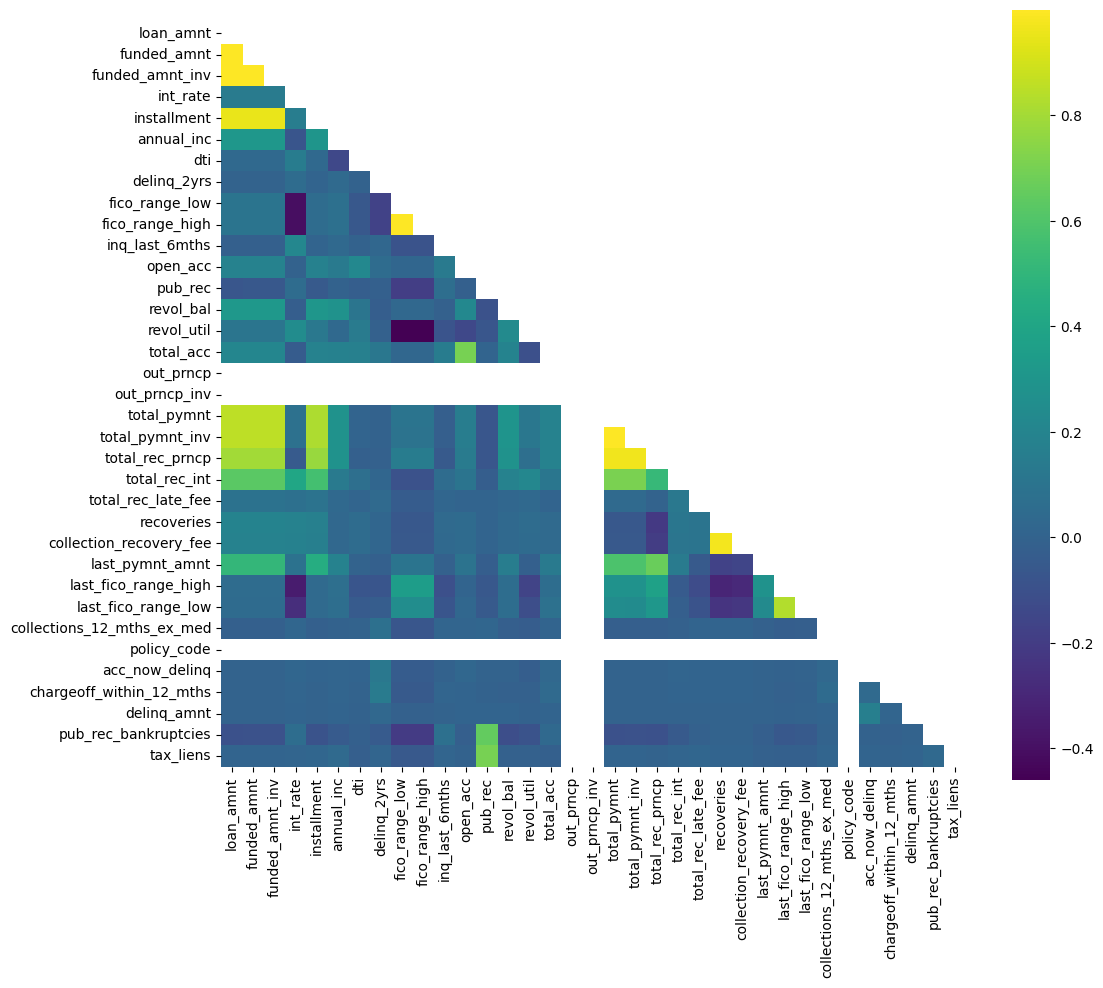

In [ ]:
df_numeric = df_accepted.select_dtypes(include=[np.number])

plt.figure(figsize=(12,10))
mask = np.zeros_like(df_numeric.corr())
mask[np.triu_indices_from(mask)] = True
sns.heatmap(df_numeric.corr(), cmap='viridis', mask=mask, annot=False, square=True)

In [ ]:
print(df_accepted.out_prncp.value_counts())
print(df_accepted.out_prncp_inv.value_counts())
print(df_accepted.policy_code.value_counts())

out_prncp
0.0    1341026
Name: count, dtype: int64
out_prncp_inv
0.0    1341026
Name: count, dtype: int64
policy_code
1.0    1341026
Name: count, dtype: int64


In [ ]:
cols_to_drop = ['out_prncp', 'out_prncp_inv', 'policy_code']
df_accepted = df_accepted.drop(columns=cols_to_drop)
df_accepted.shape

(1341026, 53)

<Axes: >

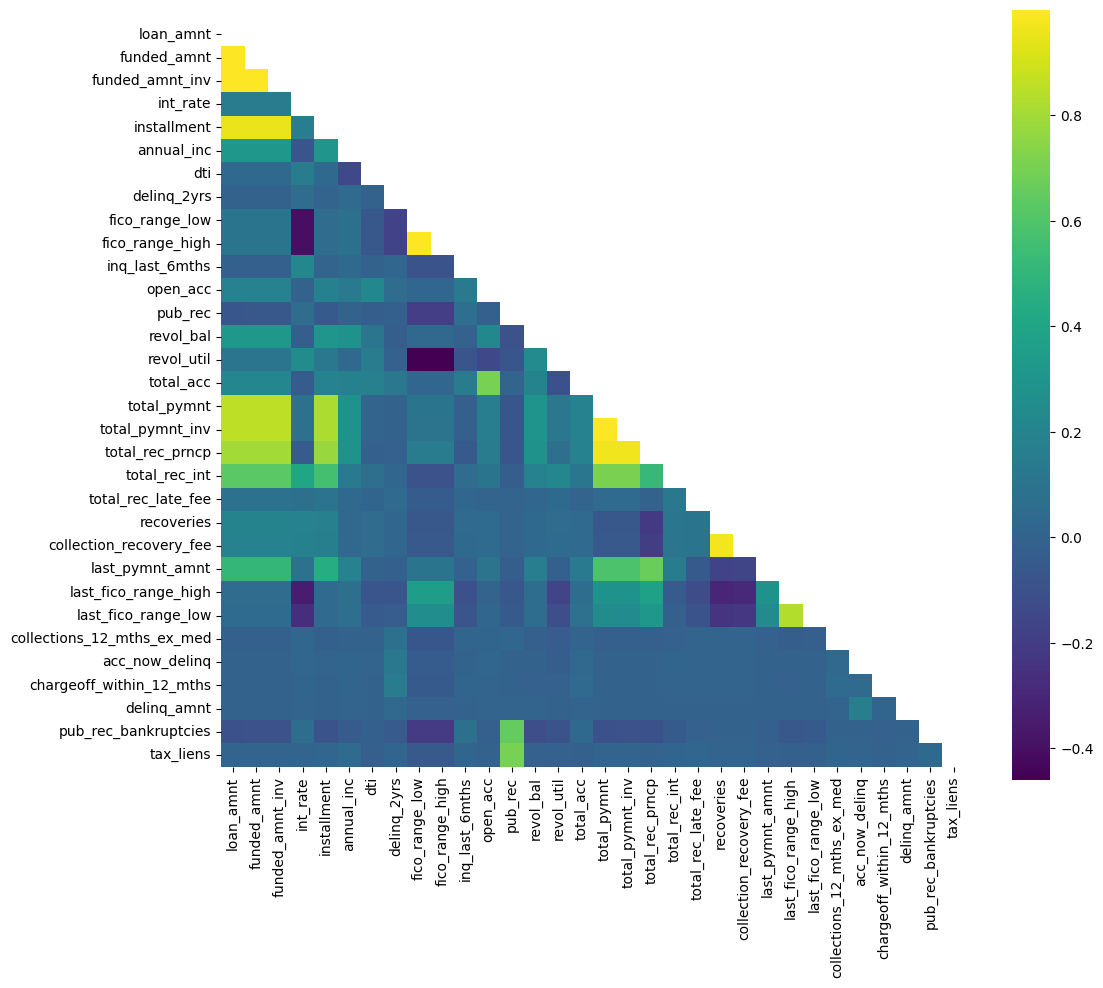

In [ ]:
df_numeric = df_accepted.select_dtypes(include=[np.number])

plt.figure(figsize=(12,10))
mask = np.zeros_like(df_numeric.corr())
mask[np.triu_indices_from(mask)] = True
sns.heatmap(df_numeric.corr(), cmap='viridis', mask=mask, annot=False, square=True)

In [ ]:
# unstacking correlation to check highest correlation pairs

c = df_numeric.corr().abs()
unstack_corr = c.unstack()
pairs = unstack_corr.sort_values(ascending=False)

corr_pairs = pd.DataFrame(pairs).drop_duplicates().reset_index()
corr_pairs.columns = ['feature1', 'feature2', 'corr']


# check feature pairs above 0.8 in correlation

cond1 = (corr_pairs.feature1 != corr_pairs.feature2)
cond2 = (corr_pairs['corr']>0.80)

corr_pairs[cond1 & cond2]

,feature1,feature2,corr
1,fico_range_high,fico_range_low,1.000000
2,loan_amnt,funded_amnt,0.999565
3,total_pymnt_inv,total_pymnt,0.999541
4,funded_amnt,funded_amnt_inv,0.999439
5,funded_amnt_inv,loan_amnt,0.998918
6,recoveries,collection_recovery_fee,0.972674
7,total_rec_prncp,total_pymnt,0.967104
8,total_pymnt_inv,total_rec_prncp,0.966725
9,funded_amnt,installment,0.954037
10,funded_amnt_inv,installment,0.953445


<Axes: xlabel='fico_range_low', ylabel='fico_range_high'>

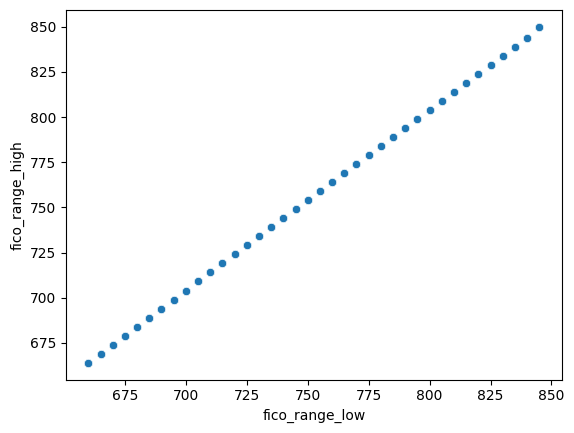

In [ ]:
sns.scatterplot(x=df_accepted.fico_range_low, y=df_accepted.fico_range_high)

<Axes: xlabel='funded_amnt', ylabel='loan_amnt'>

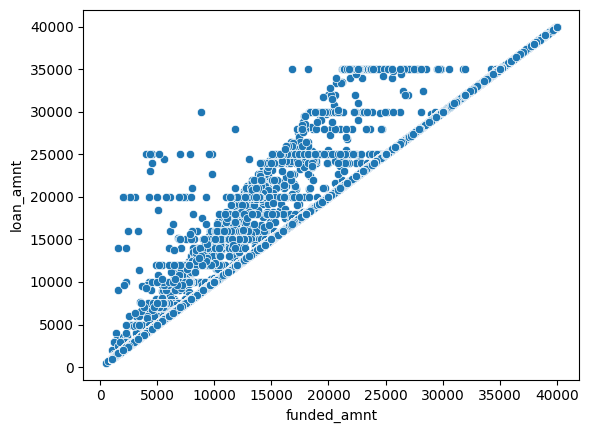

In [ ]:
sns.scatterplot(x=df_accepted.funded_amnt, y=df_accepted.loan_amnt)

<Axes: xlabel='funded_amnt', ylabel='funded_amnt_inv'>

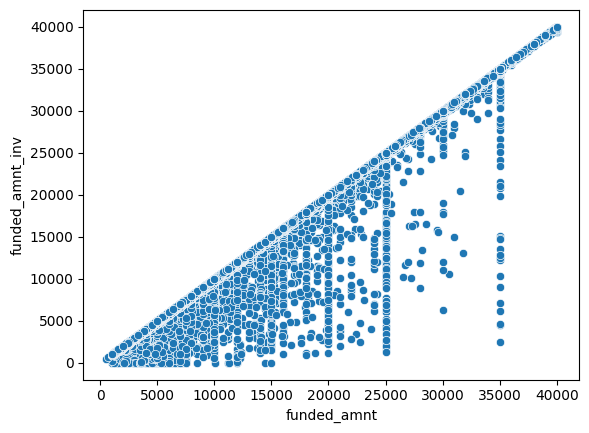

In [ ]:
sns.scatterplot(x=df_accepted.funded_amnt, y=df_accepted.funded_amnt_inv)

<Axes: xlabel='total_pymnt', ylabel='installment'>

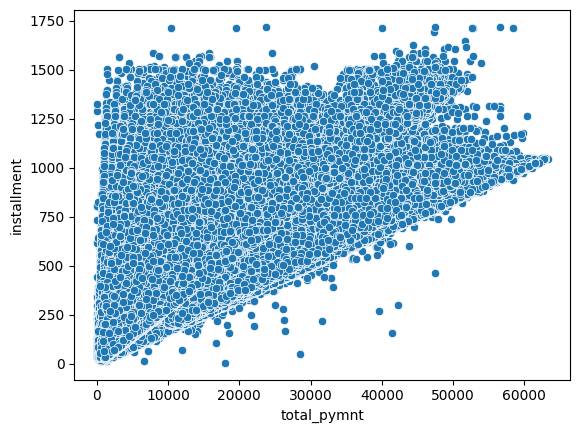

In [ ]:
sns.scatterplot(x=df_accepted.total_pymnt, y=df_accepted.installment)

In [ ]:
cols_to_drop = ['fico_range_low', 'funded_amnt_inv', 'funded_amnt', 'total_pymnt_inv', 'total_pymnt', 'installment', 'collection_recovery_fee', 'total_rec_prncp', 'last_fico_range_low']
df_accepted = df_accepted.drop(columns=cols_to_drop)
df_accepted.shape

(1341026, 44)

In [ ]:
print(df_accepted.columns)

Index(['id', 'loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'loan_status', 'pymnt_plan', 'url', 'purpose', 'zip_code', 'addr_state',
       'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_high',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'initial_list_status', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'last_pymnt_d', 'last_pymnt_amnt',
       'last_credit_pull_d', 'last_fico_range_high',
       'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq',
       'chargeoff_within_12_mths', 'delinq_amnt', 'pub_rec_bankruptcies',
       'tax_liens', 'hardship_flag', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='object')


In [ ]:
values = df_accepted.loan_status.unique()
encode = [1,0]
d = dict(zip(values, encode))

In [ ]:
df_accepted['loan_paid'] = df_accepted['loan_status'].map(d)

df_accepted = df_accepted.drop(columns=['loan_status'])

<Axes: >

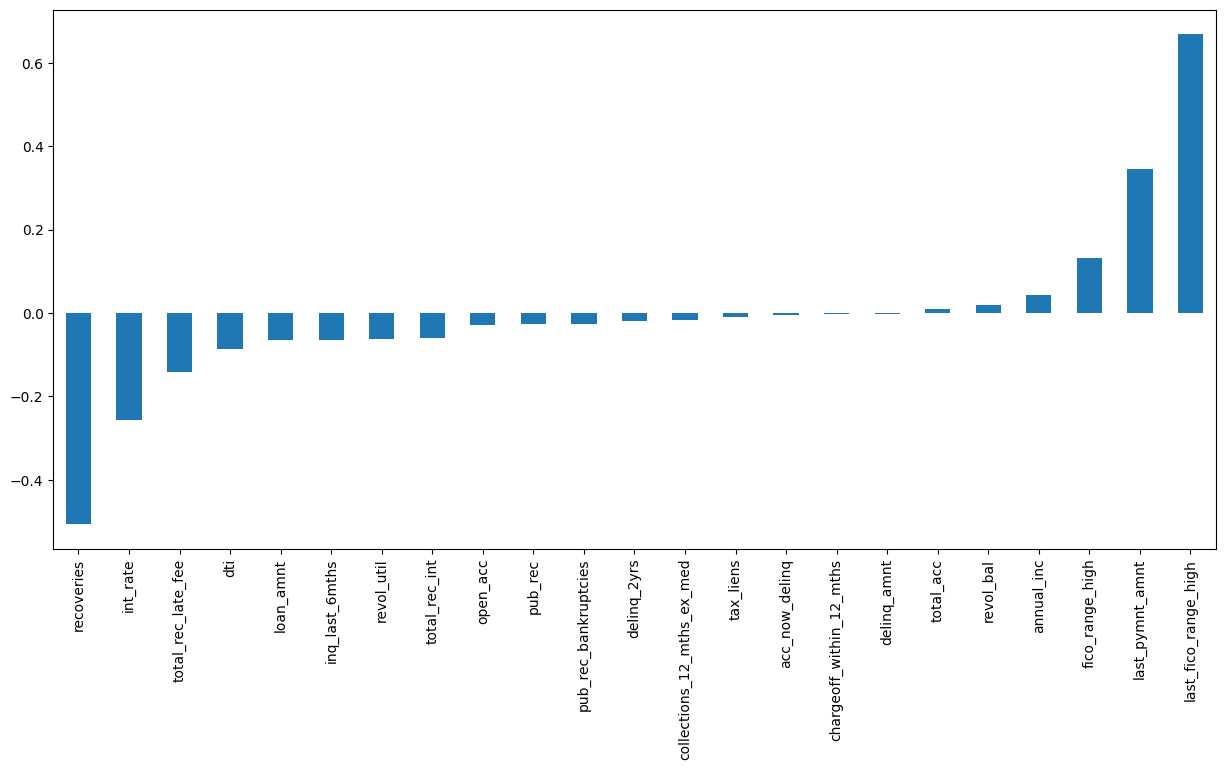

In [ ]:
df_numeric = df_accepted.select_dtypes(include=[np.number])

# checking correlation of features to the new loan_paid column

plt.figure(figsize=(15,7))
new_corr = df_numeric.corr().iloc[:-1,-1].sort_values()
new_corr.plot.bar(rot=90)

In [ ]:
df_accepted.head()

,id,loan_amnt,term,int_rate,grade,sub_grade,home_ownership,annual_inc,verification_status,issue_d,...,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag,disbursement_method,debt_settlement_flag,loan_paid
0,68407277,3600.0,36 months,13.99,C,C4,MORTGAGE,55000.0,Not Verified,Dec-2015,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,1
1,68355089,24700.0,36 months,11.99,C,C1,MORTGAGE,65000.0,Not Verified,Dec-2015,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,1
2,68341763,20000.0,60 months,10.78,B,B4,MORTGAGE,63000.0,Not Verified,Dec-2015,...,Joint App,0.0,0.0,0.0,0.0,0.0,N,Cash,N,1
4,68476807,10400.0,60 months,22.45,F,F1,MORTGAGE,104433.0,Source Verified,Dec-2015,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,1
5,68426831,11950.0,36 months,13.44,C,C3,RENT,34000.0,Source Verified,Dec-2015,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,1


In [ ]:
cat_cols = df_accepted.select_dtypes(include=['object']).columns
print(cat_cols)
df_accepted[cat_cols]

Index(['id', 'term', 'grade', 'sub_grade', 'home_ownership',
       'verification_status', 'issue_d', 'pymnt_plan', 'url', 'purpose',
       'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status',
       'last_pymnt_d', 'last_credit_pull_d', 'application_type',
       'hardship_flag', 'disbursement_method', 'debt_settlement_flag'],
      dtype='object')


,id,term,grade,sub_grade,home_ownership,verification_status,issue_d,pymnt_plan,url,purpose,zip_code,addr_state,earliest_cr_line,initial_list_status,last_pymnt_d,last_credit_pull_d,application_type,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,36 months,C,C4,MORTGAGE,Not Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,190xx,PA,Aug-2003,w,Jan-2019,Mar-2019,Individual,N,Cash,N
1,68355089,36 months,C,C1,MORTGAGE,Not Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,small_business,577xx,SD,Dec-1999,w,Jun-2016,Mar-2019,Individual,N,Cash,N
2,68341763,60 months,B,B4,MORTGAGE,Not Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,605xx,IL,Aug-2000,w,Jun-2017,Mar-2019,Joint App,N,Cash,N
4,68476807,60 months,F,F1,MORTGAGE,Source Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,major_purchase,174xx,PA,Jun-1998,w,Jul-2016,Mar-2018,Individual,N,Cash,N
5,68426831,36 months,C,C3,RENT,Source Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,300xx,GA,Oct-1987,w,May-2017,May-2017,Individual,N,Cash,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,89905081,60 months,B,B2,OWN,Not Verified,Oct-2016,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,775xx,TX,Jul-2004,f,Aug-2018,Mar-2019,Individual,N,Cash,N
2260690,88948836,60 months,C,C3,MORTGAGE,Not Verified,Oct-2016,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,900xx,CA,Mar-2002,f,Jul-2018,Jul-2018,Individual,N,Cash,N
2260691,89996426,60 months,C,C4,MORTGAGE,Source Verified,Oct-2016,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,863xx,AZ,Jun-2011,f,Mar-2017,Dec-2018,Individual,N,Cash,N
2260692,90006534,60 months,C,C1,RENT,Not Verified,Oct-2016,n,https://lendingclub.com/browse/loanDetail.acti...,medical,284xx,NC,Aug-1997,f,Mar-2018,Mar-2019,Individual,N,Cash,N


In [ ]:
# droping constant columns

print(df_accepted.pymnt_plan.value_counts())
print(df_accepted.hardship_flag.value_counts())

cols_to_drop = ['id', 'pymnt_plan', 'hardship_flag']
df_accepted = df_accepted.drop(columns=cols_to_drop)
df_accepted.shape

pymnt_plan
n    1341026
Name: count, dtype: int64
hardship_flag
N    1341026
Name: count, dtype: int64


(1341026, 41)

In [ ]:
cat_cols = df_accepted.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
       'issue_d', 'url', 'purpose', 'zip_code', 'addr_state',
       'earliest_cr_line', 'initial_list_status', 'last_pymnt_d',
       'last_credit_pull_d', 'application_type', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='object')


In [ ]:
print(df_accepted.term.value_counts())

# convert term into either a 36 or 60 integer numeric data type

l1 = df_accepted.term.unique()
l2 = [36, 60]
d = dict(zip(l1, l2))

df_accepted['term'] = df_accepted['term'].map(d)

term
36 months    1017398
60 months     323628
Name: count, dtype: int64


In [ ]:
df_accepted['term']

,term
0,36
1,36
2,60
4,60
5,36
...,...
2260688,60
2260690,60
2260691,60
2260692,60


In [ ]:
cat_cols = df_accepted.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['grade', 'sub_grade', 'home_ownership', 'verification_status',
       'issue_d', 'url', 'purpose', 'zip_code', 'addr_state',
       'earliest_cr_line', 'initial_list_status', 'last_pymnt_d',
       'last_credit_pull_d', 'application_type', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='object')


In [ ]:
print(df_accepted.grade.value_counts())
print(df_accepted.sub_grade.value_counts())

grade
B    391850
C    380490
A    234657
D    200019
E     93126
F     31854
G      9030
Name: count, dtype: int64
sub_grade
C1    85247
B4    83003
B5    82327
B3    81658
C2    78960
C3    74781
C4    74173
B2    73870
B1    70992
C5    67329
A5    63892
A4    52135
D1    51092
D2    44637
A1    43634
D3    39134
A3    37900
A2    37096
D4    35412
D5    29744
E1    23657
E2    21244
E3    18279
E4    15621
E5    14325
F1     9914
F2     7149
F3     6055
F4     4826
F5     3910
G1     2967
G2     2109
G3     1600
G4     1259
G5     1095
Name: count, dtype: int64


<Axes: xlabel='grade', ylabel='count'>

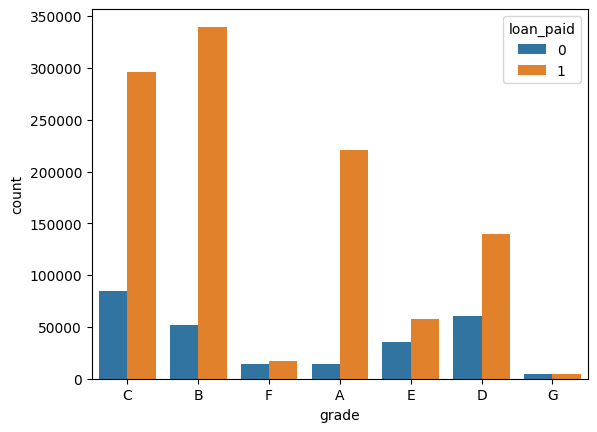

In [ ]:
# checking count per grade and loan_paid

sns.countplot(x=df_accepted.grade, hue=df_accepted.loan_paid)

<Axes: xlabel='sub_grade', ylabel='count'>

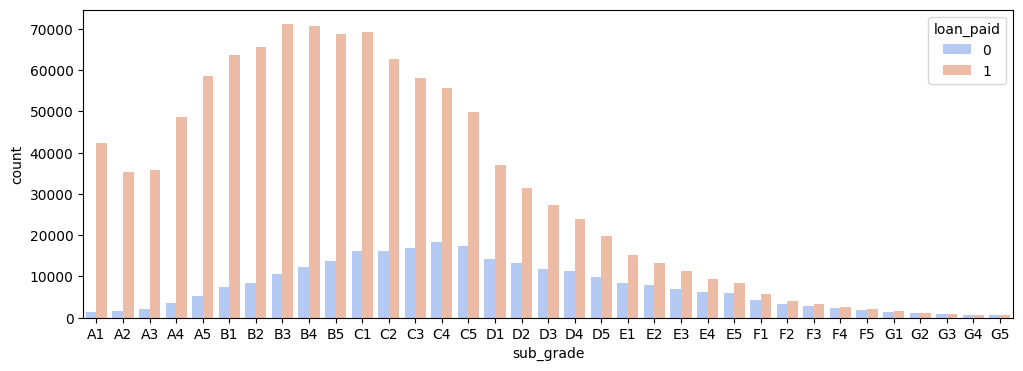

In [ ]:
# checking count per subgrade and loan_paid

l = list(df_accepted.sub_grade.unique())
l.sort()

plt.figure(figsize=(12,4))
sns.countplot(x=df_accepted.sub_grade, order=l, hue=df_accepted.loan_paid, palette='coolwarm')

In [ ]:
# as grade is part of sub_grade, so let's just drop the grade feature.

df_accepted = df_accepted.drop(columns='grade')

In [ ]:
df_accepted = pd.get_dummies(df_accepted, columns = ['sub_grade'], prefix='', prefix_sep='', drop_first=True)

In [ ]:
cat_cols = df_accepted.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['home_ownership', 'verification_status', 'issue_d', 'url', 'purpose',
       'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status',
       'last_pymnt_d', 'last_credit_pull_d', 'application_type',
       'disbursement_method', 'debt_settlement_flag'],
      dtype='object')


In [ ]:
print(df_accepted.verification_status.unique())
print(df_accepted.application_type.unique())
print(df_accepted.initial_list_status.unique())
print(df_accepted.purpose.unique())

['Not Verified' 'Source Verified' 'Verified']
['Individual' 'Joint App']
['w' 'f']
['debt_consolidation' 'small_business' 'home_improvement' 'major_purchase'
 'credit_card' 'other' 'house' 'vacation' 'car' 'medical' 'moving'
 'renewable_energy' 'wedding' 'educational']


In [ ]:
# for these columns, let's just create dummy variables, concatenate them with the original dataframe and drop original columns.

df_accepted = pd.get_dummies(df_accepted, columns = ['verification_status'], prefix='', prefix_sep='', drop_first=True)
df_accepted = pd.get_dummies(df_accepted, columns = ['application_type'], prefix='', prefix_sep='', drop_first=True)
df_accepted = pd.get_dummies(df_accepted, columns = ['initial_list_status'], prefix='', prefix_sep='', drop_first=True)
df_accepted = pd.get_dummies(df_accepted, columns = ['purpose'], prefix='', prefix_sep='', drop_first=True)

In [ ]:
cat_cols = df_accepted.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['home_ownership', 'issue_d', 'url', 'zip_code', 'addr_state',
       'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d',
       'disbursement_method', 'debt_settlement_flag'],
      dtype='object')


In [ ]:
df_accepted.home_ownership.value_counts()

,count
home_ownership,
MORTGAGE,663868
RENT,532493
OWN,144195
ANY,283
OTHER,142
NONE,45


In [ ]:
df_accepted['home_ownership'] = df_accepted.home_ownership.replace('NONE', 'ANY')
df_accepted = pd.get_dummies(df_accepted, columns = ['home_ownership'], prefix='', prefix_sep='', drop_first=True)

In [ ]:
cat_cols = df_accepted.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['issue_d', 'url', 'zip_code', 'addr_state', 'earliest_cr_line',
       'last_pymnt_d', 'last_credit_pull_d', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='object')


In [ ]:
df_accepted.issue_d.head(10)

,issue_d
0,Dec-2015
1,Dec-2015
2,Dec-2015
4,Dec-2015
5,Dec-2015
6,Dec-2015
7,Dec-2015
8,Dec-2015
9,Dec-2015
12,Dec-2015


In [ ]:
df_accepted = df_accepted.drop(columns=['url', 'last_pymnt_d', 'last_credit_pull_d'])

In [ ]:
df_accepted.zip_code.value_counts()

,count
zip_code,
945xx,14964
750xx,14440
112xx,13781
606xx,12407
300xx,12087
...,...
516xx,1
511xx,1
896xx,1


In [ ]:
df_accepted = df_accepted.drop(columns=['zip_code', 'addr_state'])

In [ ]:
cat_cols = df_accepted.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['issue_d', 'earliest_cr_line', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='object')


In [ ]:
print(df_accepted.disbursement_method.value_counts())
print(df_accepted.debt_settlement_flag.value_counts())

disbursement_method
Cash         1334162
DirectPay       6864
Name: count, dtype: int64
debt_settlement_flag
N    1307844
Y      33182
Name: count, dtype: int64


In [ ]:
df_accepted = pd.get_dummies(df_accepted, columns = ['disbursement_method'], prefix='', prefix_sep='', drop_first=True)
df_accepted = pd.get_dummies(df_accepted, columns = ['debt_settlement_flag'], prefix='', prefix_sep='', drop_first=True)

In [ ]:
print(df_accepted.earliest_cr_line.value_counts())

earliest_cr_line
Aug-2001    9365
Aug-2002    9066
Sep-2003    9000
Oct-2001    8838
Aug-2000    8822
            ... 
Nov-1957       1
Aug-1951       1
May-1961       1
Aug-1955       1
Apr-1958       1
Name: count, Length: 739, dtype: int64


In [ ]:
df_accepted = df_accepted.drop(columns=['earliest_cr_line'])

In [ ]:
print(df_accepted.columns)

Index(['loan_amnt', 'term', 'int_rate', 'annual_inc', 'issue_d', 'dti',
       'delinq_2yrs', 'fico_range_high', 'inq_last_6mths', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'last_pymnt_amnt',
       'last_fico_range_high', 'collections_12_mths_ex_med', 'acc_now_delinq',
       'chargeoff_within_12_mths', 'delinq_amnt', 'pub_rec_bankruptcies',
       'tax_liens', 'loan_paid', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3',
       'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5',
       'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2',
       'G3', 'G4', 'G5', 'Source Verified', 'Verified', 'Joint App', 'w',
       'credit_card', 'debt_consolidation', 'educational', 'home_improvement',
       'house', 'major_purchase', 'medical', 'moving', 'other',
       'renewable_energy', 'small_business', 'vacation', 'wedding', 'MORTGAGE',
       'OTHER', 'OWN', 'RENT', 'Direc

In [ ]:
df_accepted['issue_year'] = pd.to_datetime(df_accepted['issue_d'], format='%b-%Y').dt.year
df_accepted['issue_year'].value_counts().sort_index()

,count
issue_year,
2007,5
2008,1104
2009,4688
2010,11497
2011,21675
2012,53260
2013,134626
2014,222822
2015,375088


In [ ]:
print(df_accepted.columns)

Index(['loan_amnt', 'term', 'int_rate', 'annual_inc', 'issue_d', 'dti',
       'delinq_2yrs', 'fico_range_high', 'inq_last_6mths', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'last_pymnt_amnt',
       'last_fico_range_high', 'collections_12_mths_ex_med', 'acc_now_delinq',
       'chargeoff_within_12_mths', 'delinq_amnt', 'pub_rec_bankruptcies',
       'tax_liens', 'loan_paid', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3',
       'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5',
       'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2',
       'G3', 'G4', 'G5', 'Source Verified', 'Verified', 'Joint App', 'w',
       'credit_card', 'debt_consolidation', 'educational', 'home_improvement',
       'house', 'major_purchase', 'medical', 'moving', 'other',
       'renewable_energy', 'small_business', 'vacation', 'wedding', 'MORTGAGE',
       'OTHER', 'OWN', 'RENT', 'Direc

In [ ]:
df_accepted = df_accepted.drop(columns=['delinq_2yrs',
                                        'revol_bal',
                                        'open_acc',
                                        'last_fico_range_high',
                                        'inq_last_6mths',
                                        'total_rec_late_fee',
                                        'total_acc',
                                        'revol_util',
                                        'last_pymnt_amnt',
                                        'delinq_amnt',
                                        'acc_now_delinq',
                                        'total_rec_int',
                                        'Y',
                                        'recoveries'])

In [ ]:
print(df_accepted.columns)

Index(['loan_amnt', 'term', 'int_rate', 'annual_inc', 'issue_d', 'dti',
       'fico_range_high', 'pub_rec', 'collections_12_mths_ex_med',
       'chargeoff_within_12_mths', 'pub_rec_bankruptcies', 'tax_liens',
       'loan_paid', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1',
       'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3',
       'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5',
       'Source Verified', 'Verified', 'Joint App', 'w', 'credit_card',
       'debt_consolidation', 'educational', 'home_improvement', 'house',
       'major_purchase', 'medical', 'moving', 'other', 'renewable_energy',
       'small_business', 'vacation', 'wedding', 'MORTGAGE', 'OTHER', 'OWN',
       'RENT', 'DirectPay', 'issue_year'],
      dtype='object')


<Axes: >

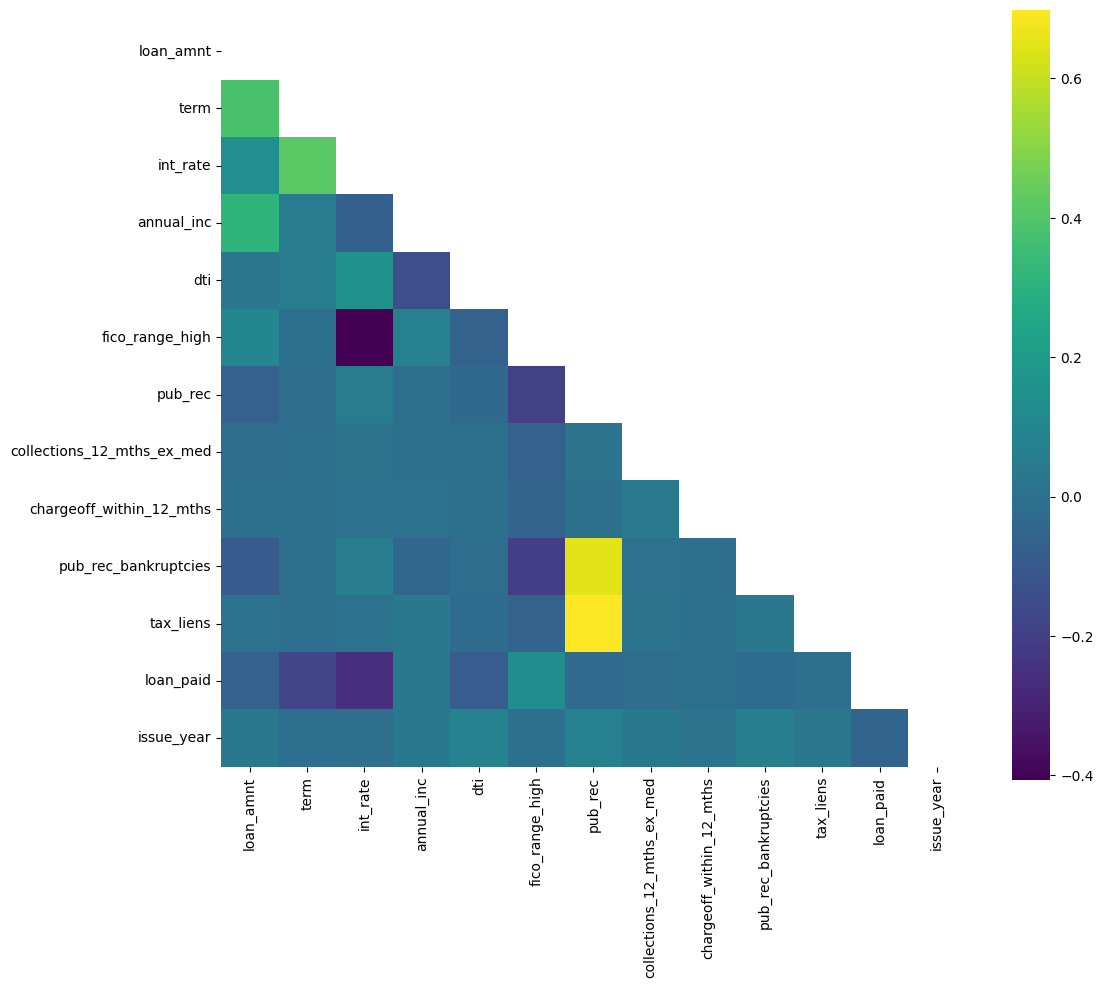

In [ ]:
df_numeric = df_accepted.select_dtypes(include=[np.number])

plt.figure(figsize=(12,10))
mask = np.zeros_like(df_numeric.corr())
mask[np.triu_indices_from(mask)] = True
sns.heatmap(df_numeric.corr(), cmap='viridis', mask=mask, annot=False, square=True)

In [ ]:
# Neural Network

# sampling data
# df = df_accepted.sample(frac=0.8, random_state=42)
# print(len(df))

df = df_accepted.copy()

# Garantir que issue_d está no formato datetime e ordenar cronologicamente
df['issue_d'] = pd.to_datetime(df['issue_d'])
df = df.sort_values('issue_d').reset_index(drop=True)

# Calcular os índices de corte
n = len(df)
train_end = int(n * 0.70)   # 70% treino
test_end  = int(n * 0.80)   # 10% teste (90% - 70%)
                             # 20% teste final (100% - 90%)

# Separar os conjuntos mantendo a ordem temporal
train_df      = df.iloc[:train_end]
test_df       = df.iloc[train_end:test_end]
test_final_df = df.iloc[test_end:]

# Verificação dos períodos de cada conjunto
print("Treino:     ", train_df['issue_d'].min().date(), "→", train_df['issue_d'].max().date(), f"({len(train_df):,} registros)")
print("Teste:      ", test_df['issue_d'].min().date(), "→", test_df['issue_d'].max().date(), f"({len(test_df):,} registros)")
print("Teste Final:", test_final_df['issue_d'].min().date(), "→", test_final_df['issue_d'].max().date(), f"({len(test_final_df):,} registros)")

# Remover issue_d antes de gerar X e y (usado apenas para ordenação)
cols_to_exclude = ['loan_paid', 'issue_d']

X_train      = train_df.drop(columns=cols_to_exclude).values
y_train      = train_df['loan_paid'].values

X_test       = test_df.drop(columns=cols_to_exclude).values
y_test       = test_df['loan_paid'].values

X_test_final = test_final_df.drop(columns=cols_to_exclude).values
y_test_final = test_final_df['loan_paid'].values

/tmp/ipykernel_10521/1170565309.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_d'] = pd.to_datetime(df['issue_d'])


Treino:      2007-10-01 → 2016-04-01 (938,718 registros)
Teste:       2016-04-01 → 2016-10-01 (134,102 registros)
Teste Final: 2016-10-01 → 2018-12-01 (268,206 registros)


In [ ]:
scaler = MinMaxScaler()


X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_test_final = scaler.transform(X_test_final)

# Verifique as formas dos conjuntos de dados
print("Tamanho do conjunto de treino:", X_train.shape)
print("Tamanho do conjunto de teste:", X_test.shape)
print("Tamanho do conjunto de teste final:", X_test_final.shape)


Tamanho do conjunto de treino: (938718, 68)
Tamanho do conjunto de teste: (134102, 68)
Tamanho do conjunto de teste final: (268206, 68)


In [ ]:
# Building Model 1

# model1 = Sequential()
# model1.add(Dense(units=78,activation='relu'))
# model1.add(Dense(units=39,activation='relu'))
# model1.add(Dense(units=19,activation='relu'))
# model1.add(Dense(units=8,activation='relu'))
# model1.add(Dense(units=4,activation='relu'))
# model1.add(Dense(units=1,activation='sigmoid'))

# model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# model1.fit(x=X_train,
#           y=y_train,
#           epochs=40,
#           batch_size=512,
#           validation_data=(X_test, y_test), verbose=1)

In [ ]:
# building model2

model2 = Sequential()
model2.add(Dense(units=64,activation='relu'))
model2.add(Dense(units=32,activation='relu'))
model2.add(Dense(units=8,activation='relu'))
model2.add(Dense(units=4,activation='relu'))
model2.add(Dense(units=1,activation='sigmoid'))

model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model2.fit(x=X_train,
          y=y_train,
          epochs=40,
          batch_size=512,
          validation_data=(X_test, y_test), verbose=1)

Epoch 1/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8137 - loss: 0.4460 - val_accuracy: 0.7484 - val_loss: 0.5335
Epoch 2/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8145 - loss: 0.4357 - val_accuracy: 0.7525 - val_loss: 0.5278
Epoch 3/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8166 - loss: 0.4343 - val_accuracy: 0.7508 - val_loss: 0.5227
Epoch 4/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8168 - loss: 0.4337 - val_accuracy: 0.7527 - val_loss: 0.5233
Epoch 5/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8169 - loss: 0.4332 - val_accuracy: 0.7538 - val_loss: 0.5241
Epoch 6/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8170 - loss: 0.4330 - val_accuracy: 0.7526 - val_loss: 0.5271
Epoch 7/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8172 - loss: 0.4329 - val_accuracy: 0.7527 - val_loss: 0.5242
Epoch 8/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8172 - loss: 0.4328 - 

In [ ]:
# # building model3

# model3 = Sequential()
# model3.add(Dense(units=8,activation='relu'))
# model3.add(Dense(units=1,activation='sigmoid'))

# model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# model3.fit(x=X_train,
#           y=y_train,
#           epochs=40,
#           batch_size=512,
#           validation_data=(X_test, y_test), verbose=1)

In [ ]:
# building model4

model4 = Sequential()
model4.add(Dense(units=128,activation='relu'))
model4.add(Dense(units=64,activation='relu'))
model4.add(Dense(units=32,activation='relu'))
model4.add(Dense(units=8,activation='relu'))
model4.add(Dense(units=4,activation='relu'))
model4.add(Dense(units=1,activation='sigmoid'))

model4.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model4.fit(x=X_train,
          y=y_train,
          epochs=40,
          batch_size=128,
          validation_data=(X_test, y_test), verbose=1)

Epoch 1/40
7334/7334 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.8150 - loss: 0.4385 - val_accuracy: 0.7527 - val_loss: 0.5329
Epoch 2/40
7334/7334 ━━━━━━━━━━━━━━━━━━━━ 7s 1000us/step - accuracy: 0.8162 - loss: 0.4347 - val_accuracy: 0.7522 - val_loss: 0.5301
Epoch 3/40
7334/7334 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8166 - loss: 0.4340 - val_accuracy: 0.7541 - val_loss: 0.5219
Epoch 4/40
7334/7334 ━━━━━━━━━━━━━━━━━━━━ 7s 990us/step - accuracy: 0.8168 - loss: 0.4335 - val_accuracy: 0.7528 - val_loss: 0.5247
Epoch 5/40
7334/7334 ━━━━━━━━━━━━━━━━━━━━ 7s 995us/step - accuracy: 0.8171 - loss: 0.4331 - val_accuracy: 0.7540 - val_loss: 0.5298
Epoch 6/40
7334/7334 ━━━━━━━━━━━━━━━━━━━━ 7s 974us/step - accuracy: 0.8172 - loss: 0.4329 - val_accuracy: 0.7537 - val_loss: 0.5297
Epoch 7/40
7334/7334 ━━━━━━━━━━━━━━━━━━━━ 7s 970us/step - accuracy: 0.8172 - loss: 0.4327 - val_accuracy: 0.7536 - val_loss: 0.5231
Epoch 8/40
7334/7334 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8172 - loss

In [ ]:
# building model5

model5 = Sequential()
model5.add(Dense(units=128,activation='relu'))
model5.add(Dense(units=64,activation='relu'))
model5.add(Dense(units=32,activation='relu'))
model5.add(Dense(units=8,activation='relu'))
model5.add(Dense(units=4,activation='relu'))
model5.add(Dense(units=1,activation='sigmoid'))

model5.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model5.fit(x=X_train,
          y=y_train,
          epochs=40,
          batch_size=32,
          validation_data=(X_test, y_test), verbose=1)

Epoch 1/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 28s 915us/step - accuracy: 0.8150 - loss: 0.4378 - val_accuracy: 0.7523 - val_loss: 0.5372
Epoch 2/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 26s 899us/step - accuracy: 0.8161 - loss: 0.4349 - val_accuracy: 0.7528 - val_loss: 0.5262
Epoch 3/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 26s 881us/step - accuracy: 0.8163 - loss: 0.4343 - val_accuracy: 0.7530 - val_loss: 0.5270
Epoch 4/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 27s 911us/step - accuracy: 0.8168 - loss: 0.4338 - val_accuracy: 0.7542 - val_loss: 0.5209
Epoch 5/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 27s 922us/step - accuracy: 0.8168 - loss: 0.4335 - val_accuracy: 0.7543 - val_loss: 0.5299
Epoch 6/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 27s 918us/step - accuracy: 0.8167 - loss: 0.4333 - val_accuracy: 0.7539 - val_loss: 0.5227
Epoch 7/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 27s 924us/step - accuracy: 0.8170 - loss: 0.4331 - val_accuracy: 0.7539 - val_loss: 0.5250
Epoch 8/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 27s 933us/s

In [ ]:
#losses1 = pd.DataFrame(model1.history.history)
losses2 = pd.DataFrame(model2.history.history)
#losses3 = pd.DataFrame(model3.history.history)
losses4 = pd.DataFrame(model4.history.history)
losses5 = pd.DataFrame(model5.history.history)

<Axes: >

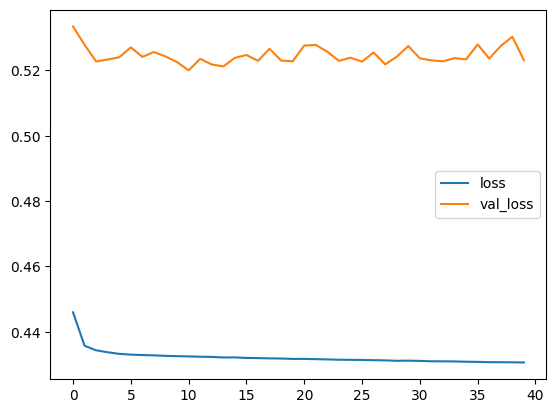

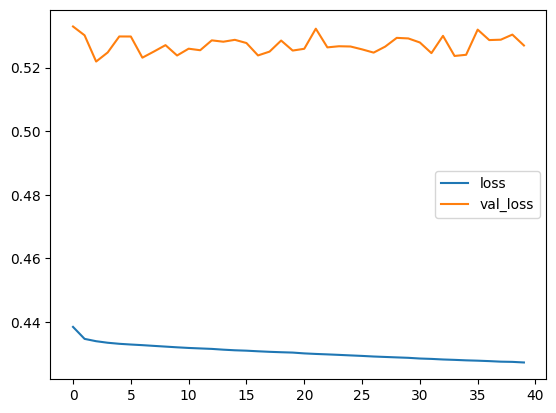

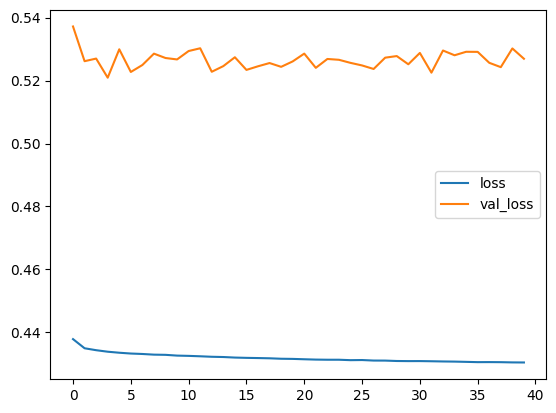

In [ ]:
#losses1[['loss','val_loss']].plot()
losses2[['loss','val_loss']].plot()
#losses3[['loss','val_loss']].plot()
losses4[['loss','val_loss']].plot()
losses5[['loss','val_loss']].plot()


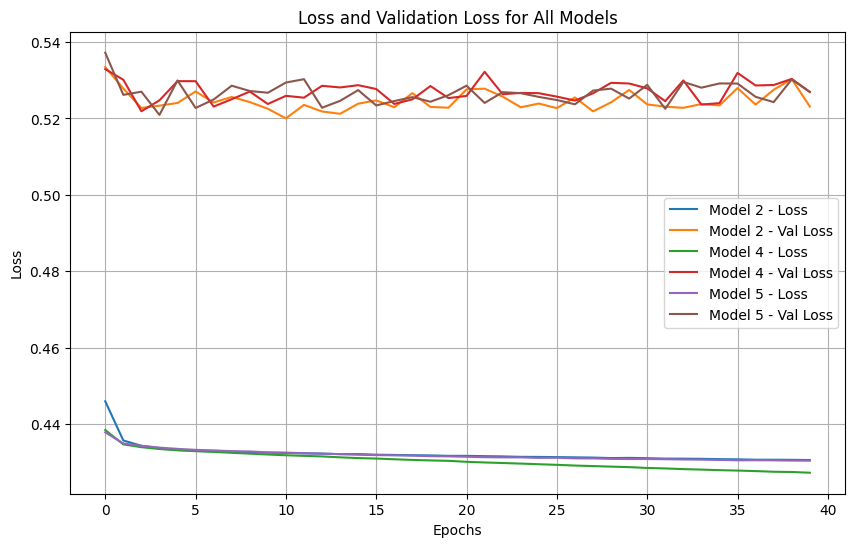

In [ ]:
import matplotlib.pyplot as plt

# Plotar as curvas de loss e val_loss para cada modelo no mesmo gráfico
plt.figure(figsize=(10, 6))  # Define o tamanho da figura

# Modelo 1
#plt.plot(losses1['loss'], label='Model 1 - Loss')
#plt.plot(losses1['val_loss'], label='Model 1 - Val Loss')

# Modelo 2
plt.plot(losses2['loss'], label='Model 2 - Loss')
plt.plot(losses2['val_loss'], label='Model 2 - Val Loss')

# Modelo 3
#plt.plot(losses3['loss'], label='Model 3 - Loss')
#plt.plot(losses3['val_loss'], label='Model 3 - Val Loss')

# Modelo 4
plt.plot(losses4['loss'], label='Model 4 - Loss')
plt.plot(losses4['val_loss'], label='Model 4 - Val Loss')

# Modelo 5
plt.plot(losses5['loss'], label='Model 5 - Loss')
plt.plot(losses5['val_loss'], label='Model 5 - Val Loss')

# Configurações adicionais do gráfico
plt.title('Loss and Validation Loss for All Models')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()  # Adiciona a legenda para identificar as curvas
plt.grid(True)  # Adiciona uma grade para facilitar a leitura

# Exibe o gráfico
plt.show()


<Axes: >

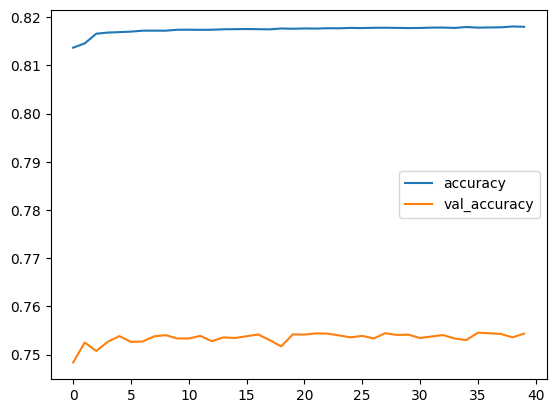

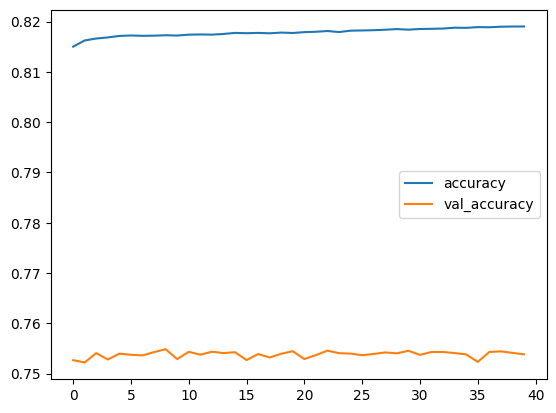

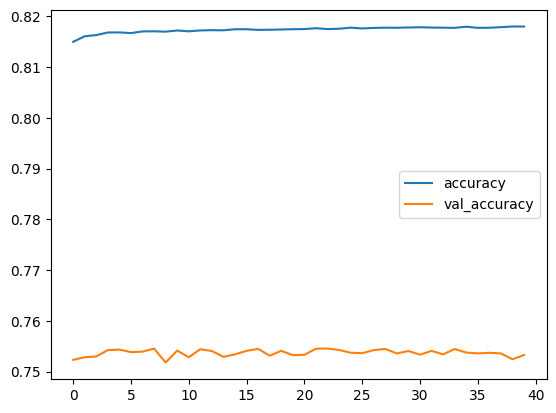

In [ ]:
#losses1[['accuracy','val_accuracy']].plot()
losses2[['accuracy','val_accuracy']].plot()
#losses3[['accuracy','val_accuracy']].plot()
losses4[['accuracy','val_accuracy']].plot()
losses5[['accuracy','val_accuracy']].plot()

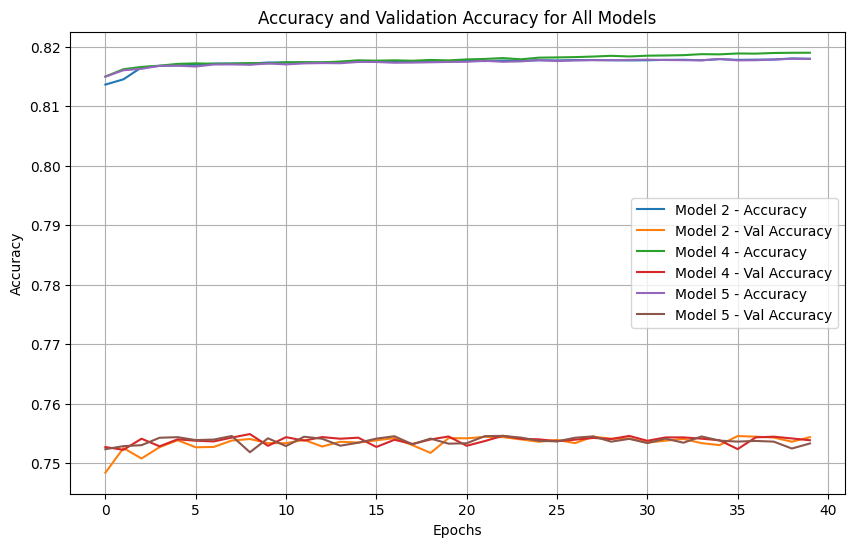

In [ ]:
import matplotlib.pyplot as plt

# Plotar as curvas de accuracy e val_accuracy para cada modelo no mesmo gráfico
plt.figure(figsize=(10, 6))  # Define o tamanho da figura

# Modelo 1
#plt.plot(losses1['accuracy'], label='Model 1 - Accuracy')
#plt.plot(losses1['val_accuracy'], label='Model 1 - Val Accuracy')

# Modelo 2
plt.plot(losses2['accuracy'], label='Model 2 - Accuracy')
plt.plot(losses2['val_accuracy'], label='Model 2 - Val Accuracy')

# Modelo 3
#plt.plot(losses3['accuracy'], label='Model 3 - Accuracy')
#plt.plot(losses3['val_accuracy'], label='Model 3 - Val Accuracy')

# Modelo 4
plt.plot(losses4['accuracy'], label='Model 4 - Accuracy')
plt.plot(losses4['val_accuracy'], label='Model 4 - Val Accuracy')

# Modelo 5
plt.plot(losses5['accuracy'], label='Model 5 - Accuracy')
plt.plot(losses5['val_accuracy'], label='Model 5 - Val Accuracy')

# Configurações adicionais do gráfico
plt.title('Accuracy and Validation Accuracy for All Models')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()  # Adiciona a legenda para identificar as curvas
plt.grid(True)  # Adiciona uma grade para facilitar a leitura

# Exibe o gráfico
plt.show()


In [ ]:
# predictions1 = (model1.predict(X_train) > 0.5).astype("int32")
# print(classification_report(y_train, predictions1))

predictions2 = (model2.predict(X_train) > 0.5).astype("int32")
print(classification_report(y_train, predictions2))

# predictions3 = (model3.predict(X_train) > 0.5).astype("int32")
# print(classification_report(y_train, predictions3))

predictions4 = (model4.predict(X_train) > 0.5).astype("int32")
print(classification_report(y_train, predictions4))

predictions5 = (model5.predict(X_train) > 0.5).astype("int32")
print(classification_report(y_train, predictions5))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.19      1.00      0.31    174662
           1       0.00      0.00      0.00    764056

    accuracy                           0.19    938718
   macro avg       0.09      0.50      0.16    938718
weighted avg       0.03      0.19      0.06    938718

29335/29335 ━━━━━━━━━━━━━━━━━━━━ 11s 386us/step
              precision    recall  f1-score   support

           0       0.58      0.08      0.14    174662
           1       0.82      0.99      0.90    764056

    accuracy                           0.82    938718
   macro avg       0.70      0.53      0.52    938718
weighted avg       0.78      0.82      0.76    938718

              precision    recall  f1-score   support

           0       0.19      1.00      0.31    174662
           1       0.00      0.00      0.00    764056

    accuracy                           0.19    938718
   macro avg       0.09      0.50      0.16    938718
weighted avg       0.03   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


29335/29335 ━━━━━━━━━━━━━━━━━━━━ 12s 417us/step
              precision    recall  f1-score   support

           0       0.60      0.08      0.15    174662
           1       0.83      0.99      0.90    764056

    accuracy                           0.82    938718
   macro avg       0.71      0.54      0.52    938718
weighted avg       0.78      0.82      0.76    938718

29335/29335 ━━━━━━━━━━━━━━━━━━━━ 13s 426us/step
              precision    recall  f1-score   support

           0       0.60      0.06      0.11    174662
           1       0.82      0.99      0.90    764056

    accuracy                           0.82    938718
   macro avg       0.71      0.53      0.51    938718
weighted avg       0.78      0.82      0.75    938718



In [ ]:
# predictions11 = model1.predict(X_test)
# print(classification_report(y_test, (predictions11> 0.5).astype("int32")))

predictions22 = model2.predict(X_test)
print(classification_report(y_test, (predictions22> 0.5).astype("int32")))

# predictions33 = model3.predict(X_test)
# print(classification_report(y_test, (predictions33> 0.5).astype("int32")))

predictions44 = model4.predict(X_test)
print(classification_report(y_test, (predictions44> 0.5).astype("int32")))

predictions55 = model5.predict(X_test)
print(classification_report(y_test, (predictions55> 0.5).astype("int32")))

              precision    recall  f1-score   support

           0       0.25      1.00      0.40     33745
           1       0.00      0.00      0.00    100357

    accuracy                           0.25    134102
   macro avg       0.13      0.50      0.20    134102
weighted avg       0.06      0.25      0.10    134102

 227/4191 ━━━━━━━━━━━━━━━━━━━━ 1s 444us/step

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


4191/4191 ━━━━━━━━━━━━━━━━━━━━ 2s 399us/step
              precision    recall  f1-score   support

           0       0.57      0.10      0.17     33745
           1       0.76      0.97      0.86    100357

    accuracy                           0.75    134102
   macro avg       0.67      0.54      0.51    134102
weighted avg       0.71      0.75      0.68    134102

              precision    recall  f1-score   support

           0       0.25      1.00      0.40     33745
           1       0.00      0.00      0.00    100357

    accuracy                           0.25    134102
   macro avg       0.13      0.50      0.20    134102
weighted avg       0.06      0.25      0.10    134102

 245/4191 ━━━━━━━━━━━━━━━━━━━━ 1s 412us/step

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


4191/4191 ━━━━━━━━━━━━━━━━━━━━ 2s 413us/step
              precision    recall  f1-score   support

           0       0.56      0.10      0.17     33745
           1       0.76      0.97      0.86    100357

    accuracy                           0.75    134102
   macro avg       0.66      0.54      0.51    134102
weighted avg       0.71      0.75      0.68    134102

4191/4191 ━━━━━━━━━━━━━━━━━━━━ 2s 419us/step
              precision    recall  f1-score   support

           0       0.58      0.07      0.13     33745
           1       0.76      0.98      0.86    100357

    accuracy                           0.75    134102
   macro avg       0.67      0.53      0.49    134102
weighted avg       0.71      0.75      0.67    134102



In [ ]:
# predictions111 = (model1.predict(X_test_final)).astype("float")

predictions222 = (model2.predict(X_test_final)).astype("float")

# predictions333 = (model3.predict(X_test_final)).astype("float")

predictions444 = (model4.predict(X_test_final)).astype("float")

predictions555 = (model5.predict(X_test_final)).astype("float")


8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 397us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 4s 430us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 403us/step


In [ ]:
# pd.DataFrame(confusion_matrix(y_test, (predictions11> 0.5).astype("int32")))


,0,1
0,33745,0
1,100357,0


In [ ]:
pd.DataFrame(confusion_matrix(y_test, (predictions22> 0.5).astype("int32")))


,0,1
0,3386,30359
1,2584,97773


In [ ]:
# pd.DataFrame(confusion_matrix(y_test, (predictions33> 0.5).astype("int32")))


,0,1
0,33745,0
1,100357,0


In [ ]:
pd.DataFrame(confusion_matrix(y_test, (predictions44> 0.5).astype("int32")))


,0,1
0,3456,30289
1,2723,97634


In [ ]:
pd.DataFrame(confusion_matrix(y_test, (predictions55> 0.5).astype("int32")))

,0,1
0,2452,31293
1,1792,98565


In [ ]:
# pd.DataFrame(confusion_matrix(y_train, predictions1))


,0,1
0,174662,0
1,764056,0


In [ ]:
pd.DataFrame(confusion_matrix(y_train, predictions2))


,0,1
0,13479,161183
1,9563,754493


In [ ]:
# pd.DataFrame(confusion_matrix(y_train, predictions3))


,0,1
0,174662,0
1,764056,0


In [ ]:
pd.DataFrame(confusion_matrix(y_train, predictions4))


,0,1
0,14772,159890
1,9765,754291


In [ ]:
pd.DataFrame(confusion_matrix(y_train, predictions5))

,0,1
0,11025,163637
1,7264,756792


In [ ]:
def ensemble_predictions(weights, y_preds):
    # Inicializa weighted_preds como float64 para evitar conflitos de tipo
    weighted_preds = np.zeros_like(y_preds[0], dtype=np.float64)
    for weight, y_pred in zip(weights, y_preds):
        weighted_preds += weight * y_pred

    # Aplicando o limiar de 0.5 para binarizar as previsões
    final_preds = (weighted_preds > 0.5).astype("int32")

    return final_preds


# Conjunto de previsões dos quatro modelos
y_preds = [#predictions11,
           predictions22, #predictions33,
           predictions44,
           predictions55]

In [ ]:
y_preds

[array([[0.5141382 ],
        [0.7117742 ],
        [0.6547495 ],
        ...,
        [0.6819278 ],
        [0.93238616],
        [0.5895414 ]], dtype=float32),
 array([[0.5124415 ],
        [0.70846784],
        [0.6497276 ],
        ...,
        [0.6848632 ],
        [0.94119   ],
        [0.64996004]], dtype=float32),
 array([[0.5421934 ],
        [0.68366945],
        [0.58549094],
        ...,
        [0.68366945],
        [0.9521696 ],
        [0.5876979 ]], dtype=float32)]

In [ ]:
!pip install deap

In [ ]:
# Esse caminho é para otimizar o precision

from deap import base, creator, tools, algorithms
import numpy as np
from sklearn.metrics import precision_score

# Definindo o problema para maximizar o precision
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

def evaluate(weights):
    # Normalizando os pesos para que somem 1
    weights = np.array(weights)
    weights = np.abs(weights)
    weights /= np.sum(weights)


# Problema aqui
    # Obtendo as previsões ponderadas
    y_ensemble_pred = ensemble_predictions(weights, y_preds)

    # Calculando o precision
    precision = precision_score(y_test, np.round(y_ensemble_pred), pos_label=1,
        zero_division=0)

    return precision,  # Retorne o precision como uma tupla

toolbox = base.Toolbox()
toolbox.register("attr_float", np.random.random)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=3)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate)

# Configuração da população e parâmetros da evolução
population = toolbox.population(n=200)
ngen = 200
cxpb = 0.6
mutpb = 0.05

# Adicionando o HallOfFame para elitismo
hof = tools.HallOfFame(1) # Mantém apenas o melhor indivíduo global

# Estatísticas para monitorar a evolução
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)


# Evoluindo a população para maximizar o precision
# Usando eaSimple para a evolução com HallOfFame e estatísticas
population, logbook = algorithms.eaSimple(population, toolbox, cxpb, mutpb, ngen,
                                            stats=stats, halloffame=hof, verbose=True)

# Pegando o melhor indivíduo (pesos otimizados para precision máximo)
best_ind = hof[0] # O melhor indivíduo está no HallOfFame
# Normalizando os pesos do melhor indivíduo para garantir que somem 1 e sejam positivos
final_best_weights = np.array(best_ind)
final_best_weights = np.abs(final_best_weights)
if np.sum(final_best_weights) == 0:
    print("Atenção: Os melhores pesos encontrados são todos zero. A normalização não é possível.")
else:
    final_best_weights /= np.sum(final_best_weights)


print("Melhores pesos encontrados para maximizar o precision (normalizados):", final_best_weights)
print("Precision máximo alcançado:", best_ind.fitness.values[0])



/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg     	std        	min     	max     
0  	200   	0.761943	0.000684578	0.759551	0.763087
1  	119   	0.762472	0.000393941	0.76109 	0.763175
2  	115   	0.762782	0.000291389	0.760437	0.763179
3  	117   	0.762987	0.000164625	0.762176	0.763224
4  	127   	0.763085	0.000115971	0.761839	0.763277
5  	139   	0.763129	0.000161263	0.761479	0.763265
6  	135   	0.763167	0.000167352	0.760905	0.763285
7  	119   	0.763189	9.56281e-05	0.762001	0.763285
8  	110   	0.7632  	0.000121303	0.762213	0.763285
9  	129   	0.763217	5.42773e-05	0.762972	0.763295
10 	121   	0.76321 	0.000178057	0.760827	0.7633  
11 	130   	0.763209	0.000203374	0.76113 	0.763298
12 	138   	0.763244	0.000101336	0.762048	0.763305
13 	112   	0.763263	9.65623e-05	0.762306	0.763305
14 	120   	0.763284	3.5829e-05 	0.762855	0.763305
15 	129   	0.763285	4.56862e-05	0.762758	0.763305
16 	119   	0.763289	4.63422e-05	0.76273 	0.763305
17 	113   	0.763294	1.92515e-05	0.7631  	0.763305
18 	127   	0.76329 	5.51706e-05	0.762539	0.763305


In [ ]:
w1 = final_best_weights.copy()

In [ ]:
# Pular essa etapa - gravei os resultados para demonstração

# import numpy as np

# scenarios_weights = {
#     'Scenario 1': np.array([3.20890885e-03, 1.80411448e-02, 9.78483859e-01, 2.66087771e-04]),
#     'Scenario 2': np.array([1.91441327e-06, 1.62920030e-02, 9.83480583e-01, 2.25499830e-04]),
#     'Scenario 3': np.array([0.00974881,     0.00190106,     0.96950776,     0.01884236]),
#     'Scenario 4': np.array([0.01188221,     0.00504466,     0.96871987,     0.01435326]),
#     'Scenario 5': np.array([0.01188221,     0.00504466,     0.96871987,     0.01435326]),
# }

# # Verificação: soma dos pesos de cada cenário
# for name, weights in scenarios_weights.items():
#     print(f"{name}: {weights} | Soma: {weights.sum():.6f}")



# w1 = np.array([3.20890885e-03, 1.80411448e-02, 9.78483859e-01, 2.66087771e-04])
# w2 = np.array([1.91441327e-06, 1.62920030e-02, 9.83480583e-01, 2.25499830e-04])
# w3 = np.array([0.00974881,     0.00190106,     0.96950776,     0.01884236])
# w4 = np.array([0.01188221,     0.00504466,     0.96871987,     0.01435326])
# w5 = np.array([0.01188221,     0.00504466,     0.96871987,     0.01435326])

In [ ]:
final_predictions = ensemble_predictions(w1, y_preds)
final_accuracy = np.mean(np.round(final_predictions) == y_test)
print("Acurácia final do ensemble:", final_accuracy)


Acurácia final do ensemble: 0.7256607959849651


In [ ]:
print(best_ind)

[0.6327134681859541, 5.841176464026396, 0.00021679396440086354]


In [ ]:
pd.DataFrame(confusion_matrix(np.round(final_predictions), y_test))

,0,1
0,3455,2674
1,30290,97683


Acurácia no conjunto de teste: 0.7541871113033363
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 392us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 400us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 4s 420us/step
Acurácia no conjunto de teste final: 0.7798930672691886


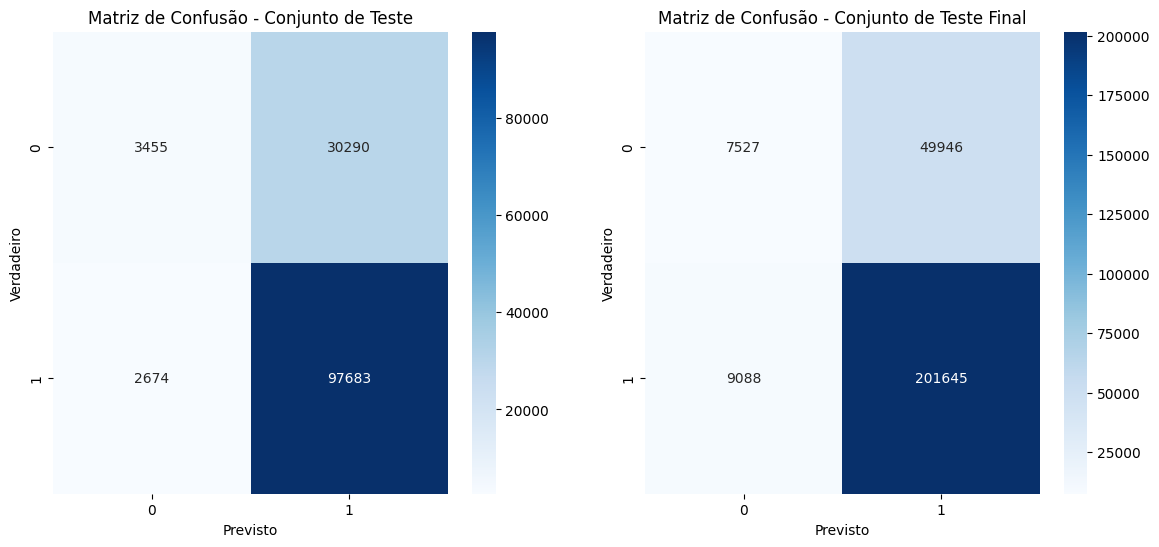

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Previsões para o conjunto de teste
final_predictions_test = ensemble_predictions(w1, y_preds)  # y_preds deve conter as previsões de cada modelo para X_test
final_accuracy_test = accuracy_score(y_test, np.round(final_predictions_test))
print("Acurácia no conjunto de teste:", final_accuracy_test)

# Previsões para o conjunto de teste final
# Aqui você precisaria gerar y_preds para X_test_final, da mesma forma que fez para X_test
# y_pred1_final = model1.predict(X_test_final)
y_pred2_final = model2.predict(X_test_final)
# y_pred3_final = model3.predict(X_test_final)
y_pred4_final = model4.predict(X_test_final)
y_pred5_final = model5.predict(X_test_final)
y_preds_final = [#y_pred1_final,
                 y_pred2_final, #y_pred3_final,
                 y_pred4_final,
                 y_pred5_final]

final_predictions_test_final = ensemble_predictions(w1, y_preds_final)
final_accuracy_test_final = accuracy_score(y_test_final, np.round(final_predictions_test_final))
print("Acurácia no conjunto de teste final:", final_accuracy_test_final)

# Matriz de Confusão para o conjunto de teste
conf_matrix_test = confusion_matrix(y_test, final_predictions_test)

# Matriz de Confusão para o conjunto de teste final
conf_matrix_test_final = confusion_matrix(y_test_final, final_predictions_test_final)

# Plotando as matrizes de confusão
plt.figure(figsize=(14, 6))

# Para o conjunto de teste
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

# Para o conjunto de teste final
plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_test_final, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste Final')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

plt.show()


In [ ]:
# Intervalo 0.8

In [ ]:
# Esse caminho é para otimizar o precision

from deap import base, creator, tools, algorithms
import numpy as np
from sklearn.metrics import precision_score

# Definindo o problema para maximizar o precision
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

def evaluate(weights):
    # Normalizando os pesos para que somem 1
    weights = np.array(weights)
    weights = np.abs(weights)
    weights /= np.sum(weights)


# Problema aqui
    # Obtendo as previsões ponderadas
    y_ensemble_pred = ensemble_predictions(weights, y_preds)

    # Calculando o precision
    precision = precision_score(y_test, np.round(y_ensemble_pred), pos_label=1,
        zero_division=0)

    return precision,  # Retorne o precision como uma tupla

toolbox = base.Toolbox()
toolbox.register("attr_float", np.random.random)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=3)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate)

# Configuração da população e parâmetros da evolução
population = toolbox.population(n=1000)
ngen = 1000
cxpb = 0.6
mutpb = 0.05

# Adicionando o HallOfFame para elitismo
hof = tools.HallOfFame(1) # Mantém apenas o melhor indivíduo global

# Estatísticas para monitorar a evolução
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)


# Evoluindo a população para maximizar o precision
# Usando eaSimple para a evolução com HallOfFame e estatísticas
population, logbook = algorithms.eaSimple(population, toolbox, cxpb, mutpb, ngen,
                                            stats=stats, halloffame=hof, verbose=True)

# Pegando o melhor indivíduo (pesos otimizados para precision máximo)
best_ind = hof[0] # O melhor indivíduo está no HallOfFame
# Normalizando os pesos do melhor indivíduo para garantir que somem 1 e sejam positivos
final_best_weights = np.array(best_ind)
final_best_weights = np.abs(final_best_weights)
if np.sum(final_best_weights) == 0:
    print("Atenção: Os melhores pesos encontrados são todos zero. A normalização não é possível.")
else:
    final_best_weights /= np.sum(final_best_weights)


print("Melhores pesos encontrados para maximizar o precision (normalizados):", final_best_weights)
print("Precision máximo alcançado:", best_ind.fitness.values[0])

/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg     	std        	min     	max     
0  	1000  	0.761875	0.000705367	0.759284	0.763253
1  	596   	0.762426	0.000514315	0.759259	0.763235
2  	564   	0.762785	0.000353996	0.759848	0.763283
3  	610   	0.762997	0.000218159	0.760408	0.763287
4  	596   	0.763108	0.000116573	0.761916	0.76331 
5  	596   	0.763159	0.000141308	0.76126 	0.76331 
6  	664   	0.763188	0.000169121	0.759906	0.76331 
7  	648   	0.763215	0.000160168	0.760061	0.76331 
8  	573   	0.763242	0.000102992	0.761174	0.76331 
9  	624   	0.763254	0.00012436 	0.760631	0.76331 
10 	644   	0.763258	0.000145801	0.760661	0.76331 
11 	602   	0.76327 	8.81732e-05	0.761636	0.76331 
12 	580   	0.763257	0.00021835 	0.759998	0.76331 
13 	677   	0.763271	0.000111008	0.760726	0.76331 
14 	616   	0.763268	0.000145614	0.761276	0.763307
15 	601   	0.763269	0.000178701	0.759717	0.763307
16 	629   	0.763272	0.00013704 	0.761339	0.763307
17 	613   	0.763279	0.000109864	0.761246	0.763307
18 	642   	0.76327 	0.000164809	0.760516	0.763307


In [ ]:
w2 = final_best_weights.copy()

In [ ]:
final_predictions = ensemble_predictions(w2, y_preds)
final_accuracy = np.mean(np.round(final_predictions) == y_test)
print("Acurácia final do ensemble:", final_accuracy)

Acurácia final do ensemble: 0.7257237655777516


In [ ]:
print(best_ind)

[0.09143351556640597, 1.0054025552621104, 0.011184364205874275]


In [ ]:
pd.DataFrame(confusion_matrix(np.round(final_predictions), y_test))

,0,1
0,3451,2661
1,30294,97696


Acurácia no conjunto de teste: 0.754254224396355
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 4s 464us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 406us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 411us/step
Acurácia no conjunto de teste final: 0.7799378089975616


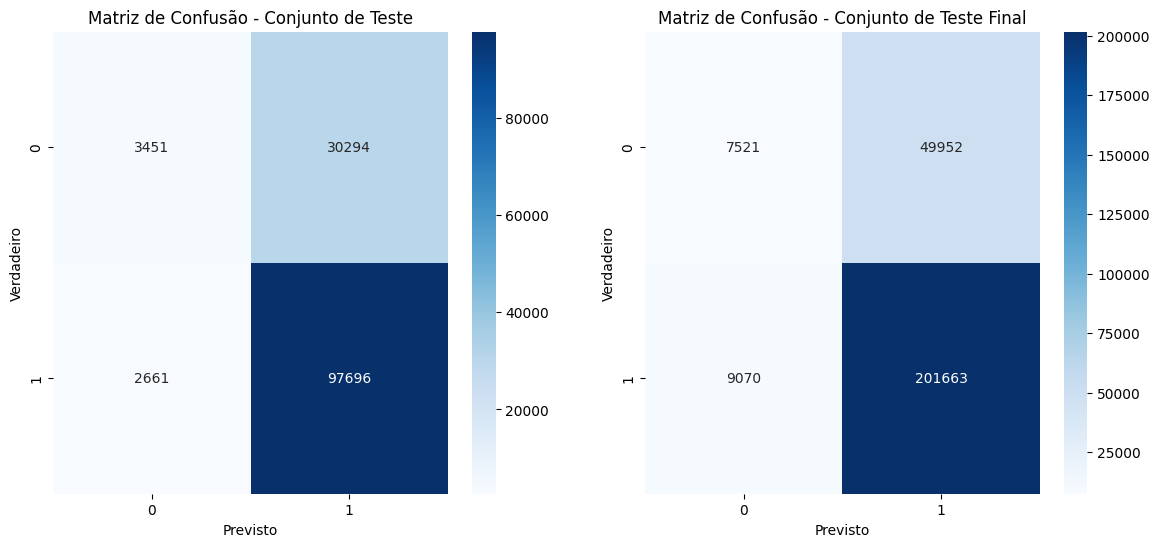

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Previsões para o conjunto de teste
final_predictions_test = ensemble_predictions(w2, y_preds)  # y_preds deve conter as previsões de cada modelo para X_test
final_accuracy_test = accuracy_score(y_test, np.round(final_predictions_test))
print("Acurácia no conjunto de teste:", final_accuracy_test)

# Previsões para o conjunto de teste final
# Aqui você precisaria gerar y_preds para X_test_final, da mesma forma que fez para X_test
# y_pred1_final = model1.predict(X_test_final)
y_pred2_final = model2.predict(X_test_final)
# y_pred3_final = model3.predict(X_test_final)
y_pred4_final = model4.predict(X_test_final)
y_pred5_final = model5.predict(X_test_final)
y_preds_final = [#y_pred1_final,
                 y_pred2_final, #y_pred3_final,
                 y_pred4_final,
                 y_pred5_final]

final_predictions_test_final = ensemble_predictions(w2, y_preds_final)
final_accuracy_test_final = accuracy_score(y_test_final, np.round(final_predictions_test_final))
print("Acurácia no conjunto de teste final:", final_accuracy_test_final)

# Matriz de Confusão para o conjunto de teste
conf_matrix_test = confusion_matrix(y_test, final_predictions_test)

# Matriz de Confusão para o conjunto de teste final
conf_matrix_test_final = confusion_matrix(y_test_final, final_predictions_test_final)

# Plotando as matrizes de confusão
plt.figure(figsize=(14, 6))

# Para o conjunto de teste
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

# Para o conjunto de teste final
plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_test_final, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste Final')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

plt.show()


In [ ]:
def ensemble_predictions(weights, y_preds):
    # Inicializa weighted_preds como float64 para evitar conflitos de tipo
    weighted_preds = np.zeros_like(y_preds[0], dtype=np.float64)
    for weight, y_pred in zip(weights, y_preds):
        weighted_preds += weight * y_pred

    # Aplicando o limiar de 0.5 para binarizar as previsões
    final_preds = (weighted_preds > 0.8).astype("int32")

    return final_preds


# Conjunto de previsões dos quatro modelos
y_preds = [#predictions11,
           predictions22, #predictions33,
           predictions44,
           predictions55]

In [ ]:
y_preds

[array([[0.5141382 ],
        [0.7117742 ],
        [0.6547495 ],
        ...,
        [0.6819278 ],
        [0.93238616],
        [0.5895414 ]], dtype=float32),
 array([[0.5124415 ],
        [0.70846784],
        [0.6497276 ],
        ...,
        [0.6848632 ],
        [0.94119   ],
        [0.64996004]], dtype=float32),
 array([[0.5421934 ],
        [0.68366945],
        [0.58549094],
        ...,
        [0.68366945],
        [0.9521696 ],
        [0.5876979 ]], dtype=float32)]

In [ ]:
pip install deap

In [ ]:
# Esse caminho é para otimizar o precision

from deap import base, creator, tools, algorithms
import numpy as np
from sklearn.metrics import precision_score

# Definindo o problema para maximizar o precision
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

def evaluate(weights):
    # Normalizando os pesos para que somem 1
    weights = np.array(weights)
    weights = np.abs(weights)
    weights /= np.sum(weights)


# Problema aqui
    # Obtendo as previsões ponderadas
    y_ensemble_pred = ensemble_predictions(weights, y_preds)

    # Calculando o precision
    precision = precision_score(y_test, np.round(y_ensemble_pred), pos_label=1,
        zero_division=0)

    return precision,  # Retorne o precision como uma tupla

toolbox = base.Toolbox()
toolbox.register("attr_float", np.random.random)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=3)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate)

# Configuração da população e parâmetros da evolução
population = toolbox.population(n=200)
ngen = 200
cxpb = 0.6
mutpb = 0.05

# Adicionando o HallOfFame para elitismo
hof = tools.HallOfFame(1) # Mantém apenas o melhor indivíduo global

# Estatísticas para monitorar a evolução
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)


# Evoluindo a população para maximizar o precision
# Usando eaSimple para a evolução com HallOfFame e estatísticas
population, logbook = algorithms.eaSimple(population, toolbox, cxpb, mutpb, ngen,
                                            stats=stats, halloffame=hof, verbose=True)

# Pegando o melhor indivíduo (pesos otimizados para precision máximo)
best_ind = hof[0] # O melhor indivíduo está no HallOfFame
# Normalizando os pesos do melhor indivíduo para garantir que somem 1 e sejam positivos
final_best_weights = np.array(best_ind)
final_best_weights = np.abs(final_best_weights)
if np.sum(final_best_weights) == 0:
    print("Atenção: Os melhores pesos encontrados são todos zero. A normalização não é possível.")
else:
    final_best_weights /= np.sum(final_best_weights)


print("Melhores pesos encontrados para maximizar o precision (normalizados):", final_best_weights)
print("Precision máximo alcançado:", best_ind.fitness.values[0])


/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg     	std        	min     	max     
0  	200   	0.847233	0.000958388	0.844589	0.848891
1  	132   	0.847993	0.00067829 	0.844666	0.848978
2  	128   	0.848495	0.000351358	0.846909	0.848978
3  	124   	0.84867 	0.000251604	0.845903	0.848978
4  	125   	0.848767	0.000111389	0.848271	0.848978
5  	128   	0.848798	0.00018257 	0.846591	0.848978
6  	128   	0.84884 	0.000127379	0.847694	0.848978
7  	128   	0.848854	0.000210429	0.846503	0.848978
8  	109   	0.848875	0.000192341	0.846981	0.848992
9  	128   	0.848873	0.000240871	0.846025	0.848992
10 	138   	0.8489  	0.000238259	0.846199	0.849008
11 	125   	0.848933	6.5467e-05 	0.848538	0.849008
12 	127   	0.848941	6.07937e-05	0.848639	0.849008
13 	137   	0.848935	0.000136985	0.847247	0.849008
14 	130   	0.848946	0.000176113	0.847184	0.849008
15 	128   	0.848966	8.48928e-05	0.848003	0.849008
16 	141   	0.848974	3.33716e-05	0.848833	0.84901 
17 	124   	0.84895 	0.00017658 	0.847367	0.84901 
18 	128   	0.848959	0.000217482	0.846649	0.84901 


In [ ]:
w3 = final_best_weights.copy()

In [ ]:
final_predictions = ensemble_predictions(w3, y_preds)
final_accuracy = np.mean(np.round(final_predictions) == y_test)
print("Acurácia final do ensemble:", final_accuracy)


Acurácia final do ensemble: 0.5051264656715668


In [ ]:
print(best_ind)

[0.6587304183829087, 0.8032818748166703, 0.0017912206109278205]


In [ ]:
pd.DataFrame(confusion_matrix(np.round(final_predictions), y_test))

,0,1
0,23412,42255
1,10333,58102


Acurácia no conjunto de teste: 0.6078507404811263
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 393us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 406us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 407us/step
Acurácia no conjunto de teste final: 0.5777424815253946


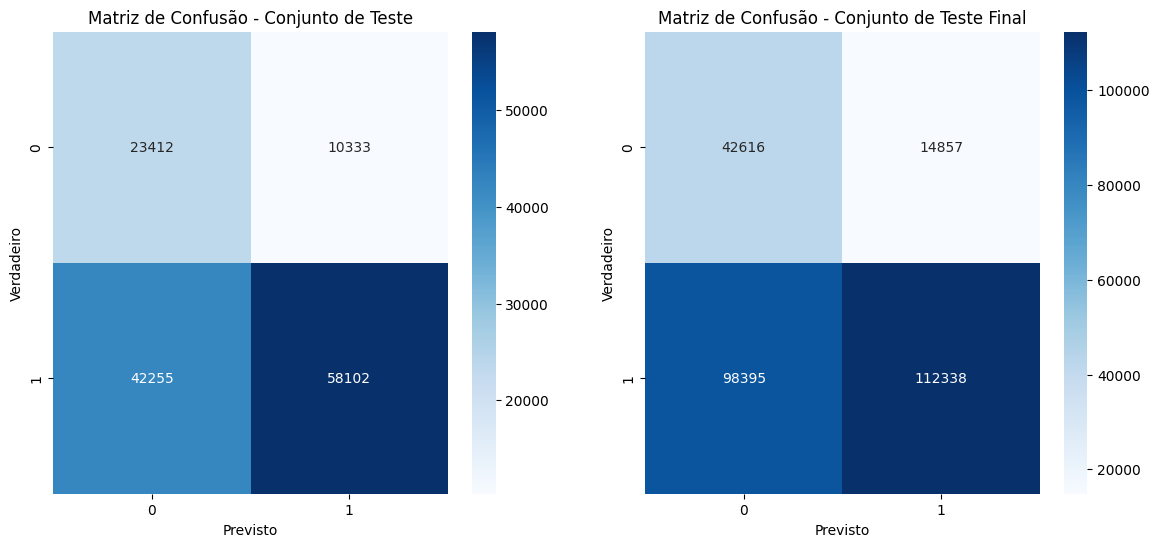

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Previsões para o conjunto de teste
final_predictions_test = ensemble_predictions(w3, y_preds)  # y_preds deve conter as previsões de cada modelo para X_test
final_accuracy_test = accuracy_score(y_test, np.round(final_predictions_test))
print("Acurácia no conjunto de teste:", final_accuracy_test)

# Previsões para o conjunto de teste final

#y_pred1_final = model1.predict(X_test_final)
y_pred2_final = model2.predict(X_test_final)
#y_pred3_final = model3.predict(X_test_final)
y_pred4_final = model4.predict(X_test_final)
y_pred5_final = model5.predict(X_test_final)
y_preds_final = [#y_pred1_final,
                 y_pred2_final, #y_pred3_final,
                 y_pred4_final,
                 y_pred5_final]

final_predictions_test_final = ensemble_predictions(w3, y_preds_final)
final_accuracy_test_final = accuracy_score(y_test_final, np.round(final_predictions_test_final))
print("Acurácia no conjunto de teste final:", final_accuracy_test_final)

# Matriz de Confusão para o conjunto de teste
conf_matrix_test = confusion_matrix(y_test, final_predictions_test)

# Matriz de Confusão para o conjunto de teste final
conf_matrix_test_final = confusion_matrix(y_test_final, final_predictions_test_final)

# Plotando as matrizes de confusão
plt.figure(figsize=(14, 6))

# Para o conjunto de teste
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

# Para o conjunto de teste final
plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_test_final, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste Final')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

plt.show()


In [ ]:
def ensemble_predictions(weights, y_preds):
    # Inicializa weighted_preds como float64 para evitar conflitos de tipo
    weighted_preds = np.zeros_like(y_preds[0], dtype=np.float64)
    for weight, y_pred in zip(weights, y_preds):
        weighted_preds += weight * y_pred

    # Aplicando o limiar de 0.5 para binarizar as previsões
    final_preds = (weighted_preds > 0.8).astype("int32")

    return final_preds


# Conjunto de previsões dos quatro modelos
y_preds = [#predictions11,
           predictions22, #predictions33,
           predictions44,
           predictions55]

In [ ]:
y_preds

[array([[0.5141382 ],
        [0.7117742 ],
        [0.6547495 ],
        ...,
        [0.6819278 ],
        [0.93238616],
        [0.5895414 ]], dtype=float32),
 array([[0.5124415 ],
        [0.70846784],
        [0.6497276 ],
        ...,
        [0.6848632 ],
        [0.94119   ],
        [0.64996004]], dtype=float32),
 array([[0.5421934 ],
        [0.68366945],
        [0.58549094],
        ...,
        [0.68366945],
        [0.9521696 ],
        [0.5876979 ]], dtype=float32)]

In [ ]:
pip install deap

In [ ]:
# Esse caminho é para otimizar o precision

from deap import base, creator, tools, algorithms
import numpy as np
from sklearn.metrics import precision_score

# Definindo o problema para maximizar o precision
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

def evaluate(weights):
    # Normalizando os pesos para que somem 1
    weights = np.array(weights)
    weights = np.abs(weights)
    weights /= np.sum(weights)


# Problema aqui
    # Obtendo as previsões ponderadas
    y_ensemble_pred = ensemble_predictions(weights, y_preds)

    # Calculando o precision
    precision = precision_score(y_test, np.round(y_ensemble_pred), pos_label=1,
        zero_division=0)

    return precision,  # Retorne o precision como uma tupla

toolbox = base.Toolbox()
toolbox.register("attr_float", np.random.random)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=3)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate)

# Configuração da população e parâmetros da evolução
population = toolbox.population(n=1000)
ngen = 1000
cxpb = 0.6
mutpb = 0.05

# Adicionando o HallOfFame para elitismo
hof = tools.HallOfFame(1) # Mantém apenas o melhor indivíduo global

# Estatísticas para monitorar a evolução
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)


# Evoluindo a população para maximizar o precision
# Usando eaSimple para a evolução com HallOfFame e estatísticas
population, logbook = algorithms.eaSimple(population, toolbox, cxpb, mutpb, ngen,
                                            stats=stats, halloffame=hof, verbose=True)

# Pegando o melhor indivíduo (pesos otimizados para precision máximo)
best_ind = hof[0] # O melhor indivíduo está no HallOfFame
# Normalizando os pesos do melhor indivíduo para garantir que somem 1 e sejam positivos
final_best_weights = np.array(best_ind)
final_best_weights = np.abs(final_best_weights)
if np.sum(final_best_weights) == 0:
    print("Atenção: Os melhores pesos encontrados são todos zero. A normalização não é possível.")
else:
    final_best_weights /= np.sum(final_best_weights)


print("Melhores pesos encontrados para maximizar o precision (normalizados):", final_best_weights)
print("Precision máximo alcançado:", best_ind.fitness.values[0])


/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg     	std        	min     	max     
0  	1000  	0.847257	0.000913941	0.844268	0.848984
1  	620   	0.847968	0.000667735	0.844061	0.848959
2  	615   	0.848433	0.000394416	0.844474	0.848969
3  	605   	0.848631	0.000278458	0.844814	0.848969
4  	656   	0.848704	0.000261644	0.8454  	0.848997
5  	606   	0.848764	0.000200692	0.846201	0.848997
6  	647   	0.848782	0.000221181	0.84641 	0.848995
7  	646   	0.848805	0.000239407	0.845434	0.848999
8  	602   	0.848831	0.000195992	0.845576	0.848997
9  	646   	0.848837	0.000193174	0.846355	0.848997
10 	601   	0.848855	0.00018613 	0.846621	0.849   
11 	612   	0.848865	0.000176337	0.845768	0.848997
12 	607   	0.848864	0.0002072  	0.846484	0.848998
13 	610   	0.848871	0.000165116	0.846443	0.848998
14 	621   	0.848881	0.000186771	0.845966	0.849003
15 	628   	0.848884	0.000159897	0.846518	0.849004
16 	644   	0.848881	0.00019828 	0.845814	0.849015
17 	615   	0.848896	0.00017776 	0.846654	0.849006
18 	640   	0.848906	0.000123876	0.846953	0.849008


In [ ]:
w4 = final_best_weights.copy()

In [ ]:
final_predictions = ensemble_predictions(w4, y_preds)
final_accuracy = np.mean(np.round(final_predictions) == y_test)
print("Acurácia final do ensemble:", final_accuracy)


Acurácia final do ensemble: 0.50517461888958


In [ ]:
print(best_ind)

[0.7326302457305008, 0.8725250468565453, 0.002104872280942238]


In [ ]:
pd.DataFrame(confusion_matrix(np.round(final_predictions), y_test))

,0,1
0,23411,42243
1,10334,58114


Acurácia no conjunto de teste: 0.6079327675948158
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 405us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 402us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 393us/step
Acurácia no conjunto de teste final: 0.5777648523895812


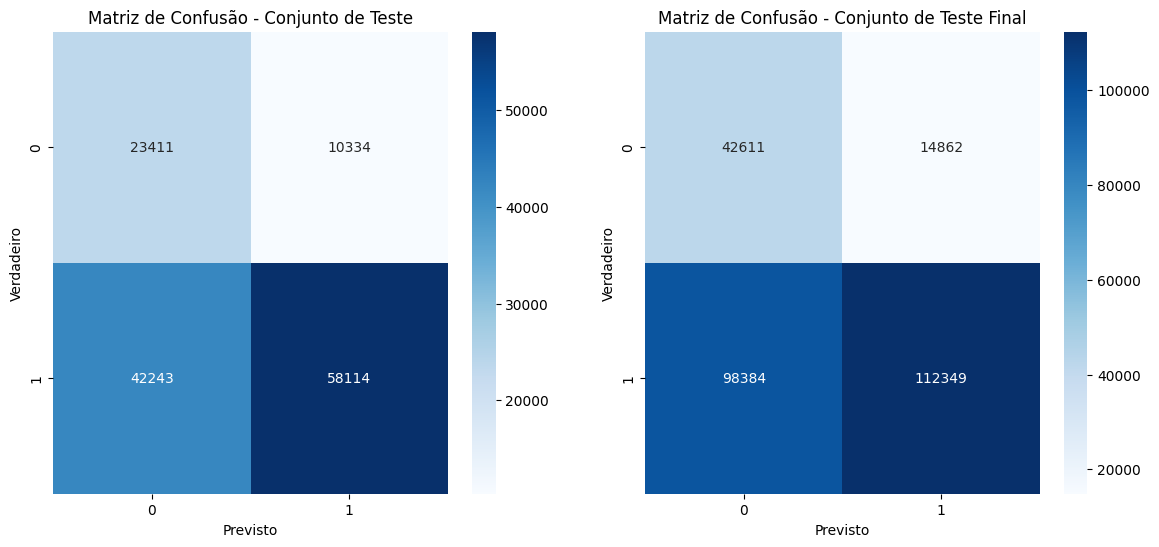

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Previsões para o conjunto de teste
final_predictions_test = ensemble_predictions(w4, y_preds)  # y_preds deve conter as previsões de cada modelo para X_test
final_accuracy_test = accuracy_score(y_test, np.round(final_predictions_test))
print("Acurácia no conjunto de teste:", final_accuracy_test)

# Previsões para o conjunto de teste final
# Aqui você precisaria gerar y_preds para X_test_final, da mesma forma que fez para X_test
# y_pred1_final = model1.predict(X_test_final)
y_pred2_final = model2.predict(X_test_final)
# y_pred3_final = model3.predict(X_test_final)
y_pred4_final = model4.predict(X_test_final)
y_pred5_final = model5.predict(X_test_final)
y_preds_final = [#y_pred1_final,
                 y_pred2_final, #y_pred3_final,
                 y_pred4_final,
                 y_pred5_final]

final_predictions_test_final = ensemble_predictions(w4, y_preds_final)
final_accuracy_test_final = accuracy_score(y_test_final, np.round(final_predictions_test_final))
print("Acurácia no conjunto de teste final:", final_accuracy_test_final)

# Matriz de Confusão para o conjunto de teste
conf_matrix_test = confusion_matrix(y_test, final_predictions_test)

# Matriz de Confusão para o conjunto de teste final
conf_matrix_test_final = confusion_matrix(y_test_final, final_predictions_test_final)

# Plotando as matrizes de confusão
plt.figure(figsize=(14, 6))

# Para o conjunto de teste
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

# Para o conjunto de teste final
plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_test_final, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste Final')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

plt.show()


In [ ]:
# y_pred1_final = model1.predict(X_test_final)
# pd.DataFrame(confusion_matrix(y_test_final, np.round(y_pred1_final)))

In [ ]:
y_pred2_final = model2.predict(X_test_final)
pd.DataFrame(confusion_matrix(y_test_final, np.round(y_pred2_final)))

8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 387us/step


,0,1
0,7432,50041
1,9072,201661


In [ ]:
# y_pred3_final = model3.predict(X_test_final)
# pd.DataFrame(confusion_matrix(y_test_final, np.round(y_pred3_final)))

In [ ]:
y_pred4_final = model4.predict(X_test_final)
pd.DataFrame(confusion_matrix(y_test_final, np.round(y_pred4_final)))

8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 410us/step


,0,1
0,7569,49904
1,9189,201544


In [ ]:
y_pred5_final = model5.predict(X_test_final)
pd.DataFrame(confusion_matrix(y_test_final, np.round(y_pred5_final)))

8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 410us/step


,0,1
0,5880,51593
1,6785,203948


In [ ]:
#drive.flush_and_unmount()

ROC AUC Score for Model 2: 0.6911
ROC AUC Score for Model 4: 0.6881
ROC AUC Score for Model 5: 0.6918


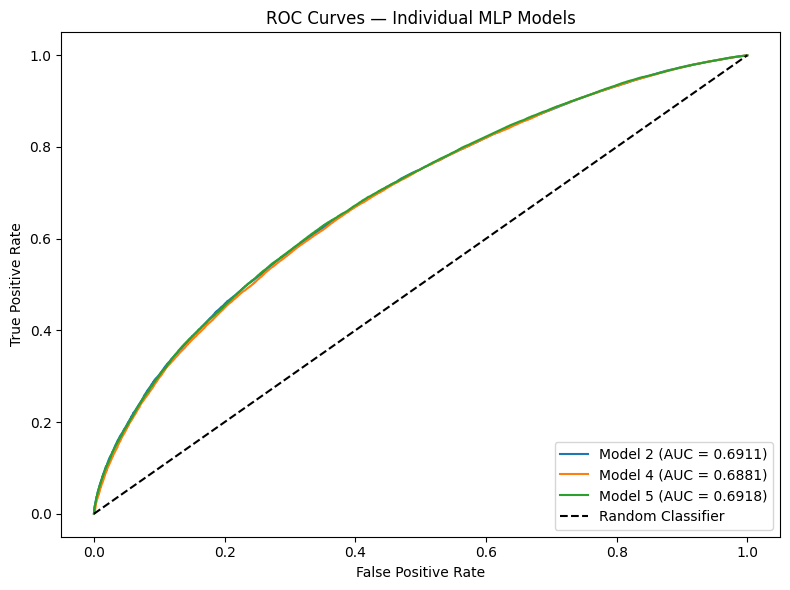

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# AUC scores
#auc_score1 = roc_auc_score(y_test, predictions11.flatten())
auc_score2 = roc_auc_score(y_test, predictions22.flatten())
# auc_score3 = roc_auc_score(y_test, predictions33.flatten())
auc_score4 = roc_auc_score(y_test, predictions44.flatten())
auc_score5 = roc_auc_score(y_test, predictions55.flatten())


# print(f"ROC AUC Score for Model 1: {auc_score1:.4f}")
print(f"ROC AUC Score for Model 2: {auc_score2:.4f}")
# print(f"ROC AUC Score for Model 3: {auc_score3:.4f}")
print(f"ROC AUC Score for Model 4: {auc_score4:.4f}")
print(f"ROC AUC Score for Model 5: {auc_score5:.4f}")

# ROC Curves
models_info = [
    # (predictions11, auc_score1, 'Model 1'),
    (predictions22, auc_score2, 'Model 2'),
    # (predictions33, auc_score3, 'Model 3'),
    (predictions44, auc_score4, 'Model 4'),
    (predictions55, auc_score5, 'Model 5'),
]

plt.figure(figsize=(8, 6))
for preds, auc, label in models_info:
    fpr, tpr, _ = roc_curve(y_test, preds.flatten())
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Individual MLP Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
scenarios_weights = {
    'Scenario 1 (thr=0.5, pop=200)' : w1,
    'Scenario 2 (thr=0.5, pop=1000)': w2,
    'Scenario 3 (thr=0.8, pop=200)' : w3,
    'Scenario 4 (thr=0.8, pop=1000)': w4,
}

# Verificação: soma dos pesos de cada cenário
for name, weights in scenarios_weights.items():
    print(f"{name}: {weights} | Soma: {weights.sum():.6f}")

Scenario 1 (thr=0.5, pop=200): [9.77298483e-02 9.02236665e-01 3.34863130e-05] | Soma: 1.000000
Scenario 2 (thr=0.5, pop=1000): [0.0825197  0.90738629 0.01009401] | Soma: 1.000000
Scenario 3 (thr=0.8, pop=200): [0.45001287 0.54876346 0.00122368] | Soma: 1.000000
Scenario 4 (thr=0.8, pop=1000): [0.45582555 0.54286485 0.0013096 ] | Soma: 1.000000


8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 397us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 4s 418us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 411us/step


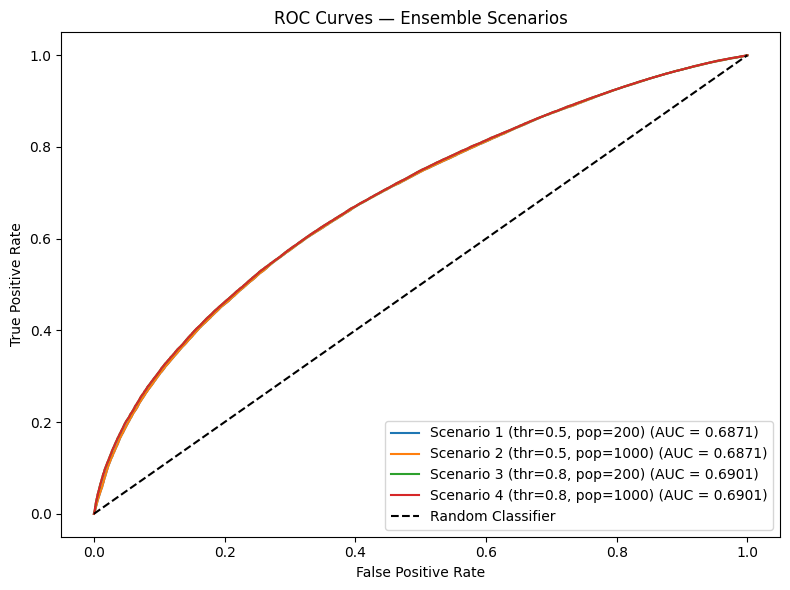

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_preds_final = [
    # model1.predict(X_test_final).flatten(),
    model2.predict(X_test_final).flatten(),
    # model3.predict(X_test_final).flatten(),
    model4.predict(X_test_final).flatten(),
    model5.predict(X_test_final).flatten(),
]

plt.figure(figsize=(8, 6))

for name, weights in scenarios_weights.items():
    preds = sum(w * p for w, p in zip(weights, y_preds_final))
    auc = roc_auc_score(y_test_final, preds)
    fpr, tpr, _ = roc_curve(y_test_final, preds)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Ensemble Scenarios')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves_ensembles.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import pandas as pd



models = [#model1,
          model2, #model3,
          model4,
          model5]
model_names = [#'Model 1',
              'Model 2', #'Model 3',
              'Model 4',
               'Model 5']

# Predições probabilísticas
probs = {}
preds = {}
errors = {}

threshold = 0.5

for name, model in zip(model_names, models):
    prob = model.predict(X_test).flatten()
    pred = (prob >= threshold).astype(int)
    error = (pred != y_test).astype(int)  # 1 onde errou, 0 onde acertou
    probs[name] = prob
    preds[name] = pred
    errors[name] = error

df_errors = pd.DataFrame(errors)
df_probs  = pd.DataFrame(probs)
df_preds  = pd.DataFrame(preds)

4191/4191 ━━━━━━━━━━━━━━━━━━━━ 2s 415us/step
4191/4191 ━━━━━━━━━━━━━━━━━━━━ 2s 399us/step
4191/4191 ━━━━━━━━━━━━━━━━━━━━ 2s 408us/step


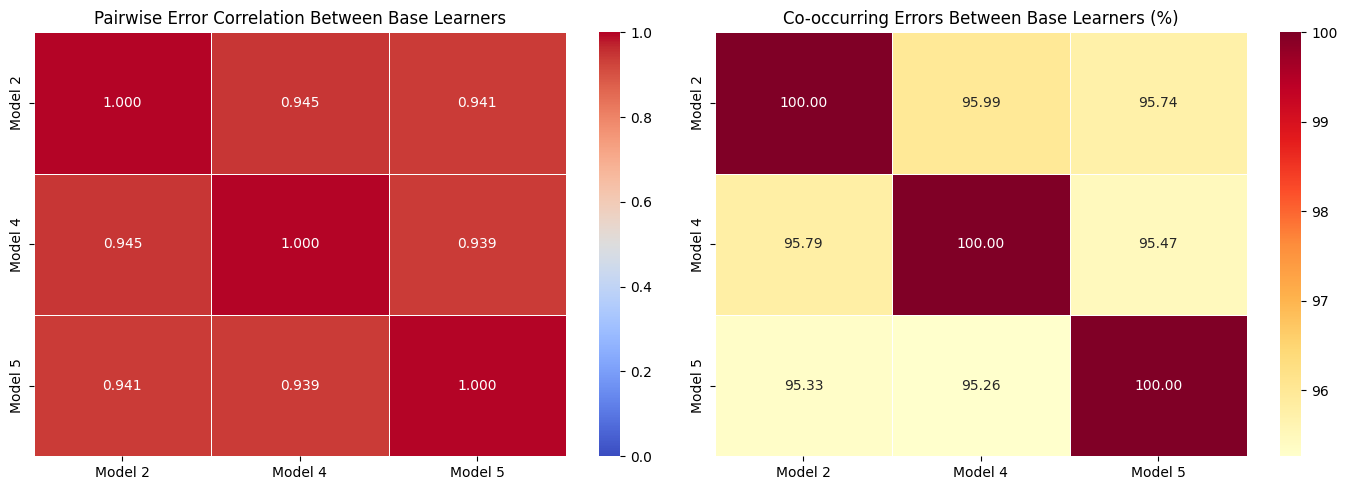


Error Correlation Matrix:
         Model 2  Model 4  Model 5
Model 2   1.0000   0.9455   0.9407
Model 4   0.9455   1.0000   0.9385
Model 5   0.9407   0.9385   1.0000

Co-occurring Errors (%):
         Model 2  Model 4  Model 5
Model 2   100.00    95.99    95.74
Model 4    95.79   100.00    95.47
Model 5    95.33    95.26   100.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlação de erros (Pearson)
error_corr = df_errors.corr()

# Coincidência de erros (% de instâncias em que ambos os modelos erram simultaneamente)
n = len(y_test)
co_error_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for m1 in model_names:
    for m2 in model_names:
        errors_m1 = (df_errors[m1] == 1).sum()
        co_errors  = ((df_errors[m1] == 1) & (df_errors[m2] == 1)).sum()
        # Dado que m1 errou, qual % também foi erro de m2?
        co_error_matrix.loc[m1, m2] = co_errors / errors_m1 * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de correlação de erros
sns.heatmap(error_corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=0, vmax=1, ax=axes[0], linewidths=0.5)
axes[0].set_title('Pairwise Error Correlation Between Base Learners')

# Heatmap de co-ocorrência de erros
sns.heatmap(co_error_matrix.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Co-occurring Errors Between Base Learners (%)')

plt.tight_layout()
plt.savefig('error_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# Tabela resumo para o paper
print("\nError Correlation Matrix:")
print(error_corr.round(4).to_string())

print("\nCo-occurring Errors (%):")
print(co_error_matrix.round(2).to_string())

In [ ]:
import pickle
import os

# 1. Montar o Drive (se ainda não montou)
from google.colab import drive
drive.mount('/content/drive')

# 2. Criar pasta
os.makedirs('/content/drive/MyDrive/lending_club_experiment/', exist_ok=True)

# 3. Salvar
to_save = {
    'y_preds'       : y_preds,
    # 'y_pred1_final' : y_pred1_final,  # <- vírgulas faltavam aqui
    'y_pred2_final' : y_pred2_final,
    # 'y_pred3_final' : y_pred3_final,
    'y_pred4_final' : y_pred4_final,
    'y_pred5_final' : y_pred5_final,
    'w1'            : w1,
    'w2'            : w2,
    'w3'            : w3,
    'w4'            : w4,
    'y_test'        : y_test,
    'y_test_final'  : y_test_final,
}

save_path = '/content/drive/MyDrive/lending_club_experiment/experiment_data_robust.pkl'

with open(save_path, 'wb') as f:
    pickle.dump(to_save, f)

print(f"Salvo com sucesso em: {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Salvo com sucesso em: /content/drive/MyDrive/lending_club_experiment/experiment_data_robust.pkl


In [ ]:
# from google.colab import drive
# import pickle

# # 1. Montar o Drive
# drive.mount('/content/drive')

# # 2. Carregar
# save_path = '/content/drive/MyDrive/lending_club_experiment/experiment_data.pkl'

# with open(save_path, 'rb') as f:
#     data = pickle.load(f)

# # 3. Restaurar as variáveis
# y_preds       = data['y_preds']
# y_pred1_final = data['y_pred1_final']
# y_pred2_final = data['y_pred2_final']
# y_pred3_final = data['y_pred3_final']
# y_pred4_final = data['y_pred4_final']
# w1            = data['w1']
# w2            = data['w2']
# w3            = data['w3']
# w4            = data['w4']
# y_test        = data['y_test']
# y_test_final  = data['y_test_final']
# #X_test        = data['X_test']
# #X_test_final  = data['X_test_final']

# print("Dados carregados com sucesso!")
# print(f"y_preds:       {len(y_preds)} modelos")
# print(f"y_pred1_final: {len(y_pred1_final)} modelos")
# print(f"y_test:        {y_test.shape}")
# print(f"y_test_final:  {y_test_final.shape}")

Aqui começam os resgatados da gravação:

In [ ]:
import numpy as np
import pandas as pd

threshold = 0.5
model_names = [#'Model 1',
               'Model 2', #'Model 3',
               'Model 4',
               'Model 5']

# Usando os preds já salvos ao invés de rodar os modelos novamente
saved_preds = [
    # y_pred1_final.flatten(),
    y_pred2_final.flatten(),
    # y_pred3_final.flatten(),
    y_pred4_final.flatten(),
    y_pred5_final.flatten(),
]

probs  = {}
preds  = {}
errors = {}

for name, prob in zip(model_names, saved_preds):
    pred  = (prob >= threshold).astype(int)
    error = (pred != y_test_final).astype(int)  # <- y_test_final, não y_test
    probs[name]  = prob
    preds[name]  = pred
    errors[name] = error

df_errors = pd.DataFrame(errors)
df_probs  = pd.DataFrame(probs)
df_preds  = pd.DataFrame(preds)

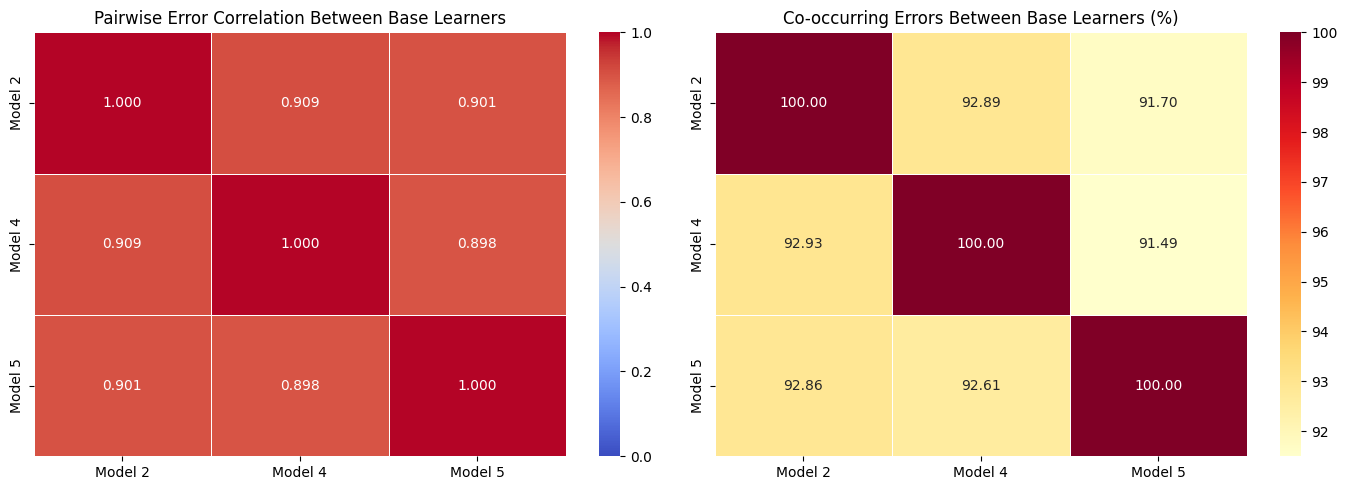


Error Correlation Matrix:
         Model 2  Model 4  Model 5
Model 2   1.0000   0.9091   0.9011
Model 4   0.9091   1.0000   0.8982
Model 5   0.9011   0.8982   1.0000

Co-occurring Errors (%):
         Model 2  Model 4  Model 5
Model 2   100.00    92.89    91.70
Model 4    92.93   100.00    91.49
Model 5    92.86    92.61   100.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlação de erros (Pearson)
error_corr = df_errors.corr()

# Coincidência de erros (% de instâncias em que ambos os modelos erram simultaneamente)
n = len(y_test)
co_error_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for m1 in model_names:
    for m2 in model_names:
        errors_m1 = (df_errors[m1] == 1).sum()
        co_errors  = ((df_errors[m1] == 1) & (df_errors[m2] == 1)).sum()
        # Dado que m1 errou, qual % também foi erro de m2?
        co_error_matrix.loc[m1, m2] = co_errors / errors_m1 * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de correlação de erros
sns.heatmap(error_corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=0, vmax=1, ax=axes[0], linewidths=0.5)
axes[0].set_title('Pairwise Error Correlation Between Base Learners')

# Heatmap de co-ocorrência de erros
sns.heatmap(co_error_matrix.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Co-occurring Errors Between Base Learners (%)')

plt.tight_layout()
plt.savefig('error_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# Tabela resumo para o paper
print("\nError Correlation Matrix:")
print(error_corr.round(4).to_string())

print("\nCo-occurring Errors (%):")
print(co_error_matrix.round(2).to_string())

In [ ]:
def ensemble_probabilities(weights, y_preds):
    weighted_preds = np.zeros_like(y_preds[0], dtype=np.float64)
    for weight, y_pred in zip(weights, y_preds):
        weighted_preds += weight * y_pred
    return weighted_preds

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

# Configuração
models_info = [
    # (y_pred1_final.flatten(), 'Model 1'),
    (y_pred2_final.flatten(), 'Model 2'),
    # (y_pred3_final.flatten(), 'Model 3'),
    (y_pred4_final.flatten(), 'Model 4'),
    (y_pred5_final.flatten(), 'Model 5'),


]

# Regenerar predições dos ensembles
y_preds_final = [y_pred1_final, y_pred2_final, y_pred3_final, y_pred4_final]

final_predictions_s1 = ensemble_probabilities(w1, y_preds_final)
final_predictions_s2 = ensemble_probabilities(w2, y_preds_final)
final_predictions_s3 = ensemble_probabilities(w3, y_preds_final)
final_predictions_s4 = ensemble_probabilities(w4, y_preds_final)

ensembles_info = [
    (final_predictions_s1.flatten(), 'Scenario 1 (thr=0.5)'),
    (final_predictions_s2.flatten(), 'Scenario 2 (thr=0.5)'),
    (final_predictions_s3.flatten(), 'Scenario 3 (thr=0.8)'),
    (final_predictions_s4.flatten(), 'Scenario 4 (thr=0.8)'),
]





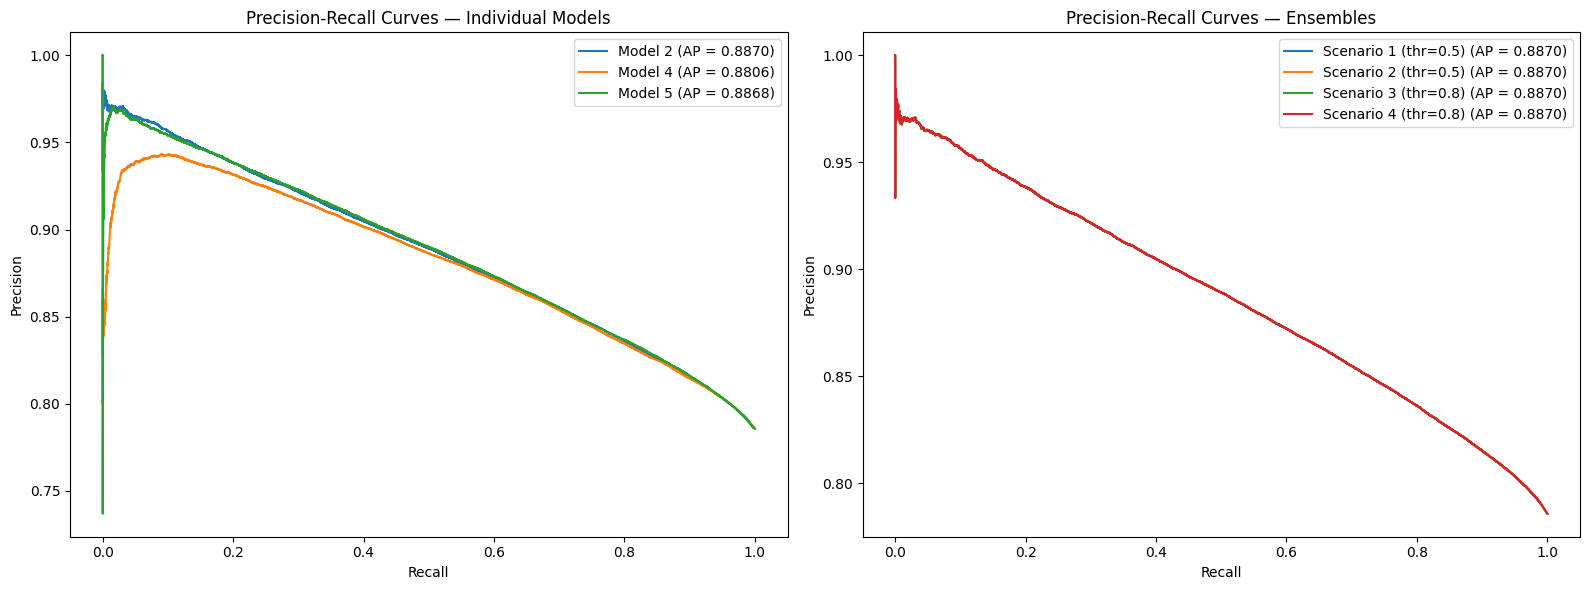

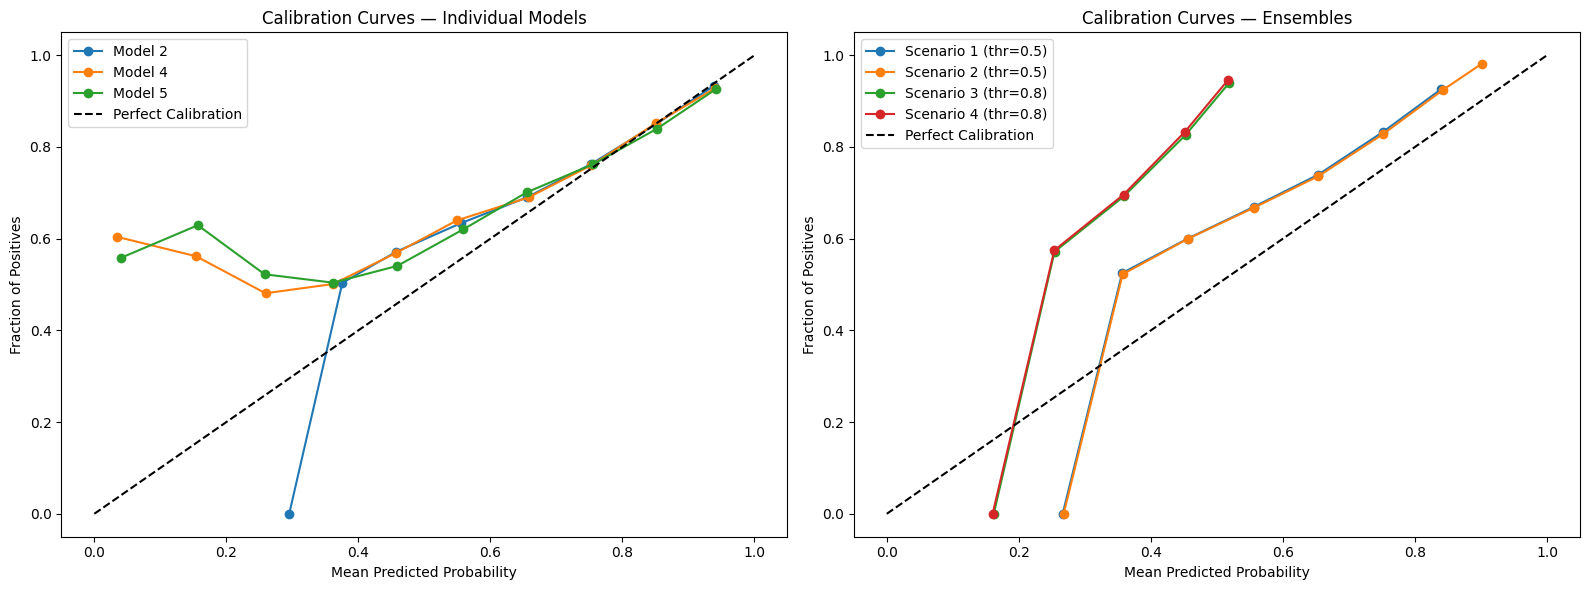

Cost FP (principal lost):      $14,422
Cost FN (interest revenue lost): $6,562

                          TP     FP      FN  Revenue TP ($)  Cost FP ($)   Cost FN ($)  Net Profit ($)
Model                                                                                                 
Model 2               201661  50041    9072    1.323301e+09    721691302  5.953055e+07    5.420796e+08
Model 4               201544  49904    9189    1.322534e+09    719715488  6.029831e+07    5.425199e+08
Model 5               203948  51593    6785    1.338309e+09    744074246  4.452324e+07    5.497113e+08
Scenario 1 (thr=0.5)  195340  46096   15393    1.281823e+09    664796512  1.010090e+08    5.160175e+08
Scenario 2 (thr=0.5)  195773  46363   14960    1.284664e+09    668647186  9.816767e+07    5.178495e+08
Scenario 3 (thr=0.8)       0      0  210733    0.000000e+00            0  1.382832e+09   -1.382832e+09
Scenario 4 (thr=0.8)       0      0  210733    0.000000e+00            0  1.382832e+09   -1.3828

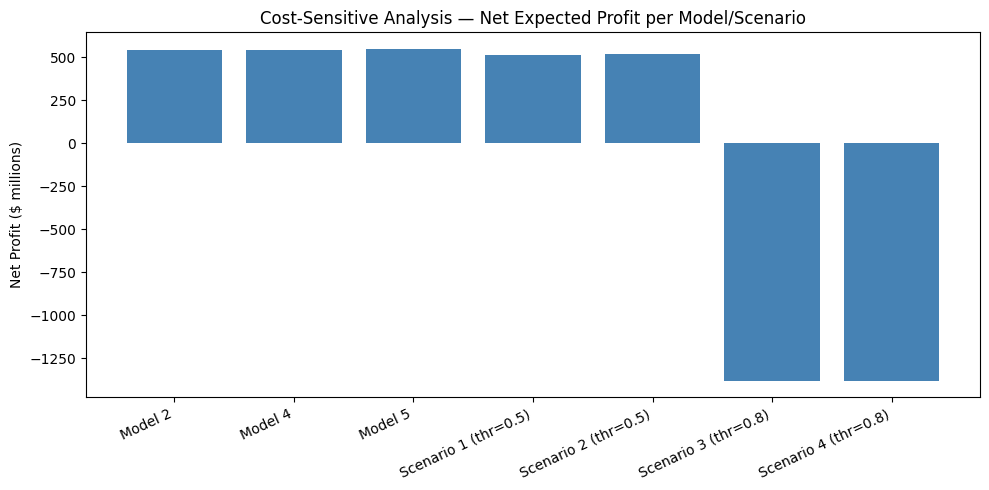

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd

# ── Bloco 1: Precision-Recall Curves ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for preds, label in models_info:
    precision, recall, _ = precision_recall_curve(y_test_final, preds)
    ap = average_precision_score(y_test_final, preds)
    axes[0].plot(recall, precision, label=f'{label} (AP = {ap:.4f})')

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves — Individual Models')
axes[0].legend(loc='upper right')

for preds, label in ensembles_info:
    precision, recall, _ = precision_recall_curve(y_test_final, preds)
    ap = average_precision_score(y_test_final, preds)
    axes[1].plot(recall, precision, label=f'{label} (AP = {ap:.4f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — Ensembles')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Bloco 2: Calibration Curves ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for preds, label in models_info:
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test_final, preds, n_bins=10
    )
    axes[0].plot(mean_predicted_value, fraction_of_positives, marker='o', label=label)

axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curves — Individual Models')
axes[0].legend(loc='upper left')

for preds, label in ensembles_info:
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test_final, preds, n_bins=10
    )
    axes[1].plot(mean_predicted_value, fraction_of_positives, marker='o', label=label)

axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Calibration Curves — Ensembles')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Bloco 3: Cost-Sensitive Analysis ──────────────────────────────────────────

avg_loan    = 14422
rate        = 0.13
term_years  = 42 / 12          # 3.5 anos
cost_FP     = avg_loan                        # perde o principal
cost_FN     = avg_loan * rate * term_years    # perde a receita de juros = $5,880

print(f"Cost FP (principal lost):      ${cost_FP:,.0f}")
print(f"Cost FN (interest revenue lost): ${cost_FN:,.0f}")
print()

all_info = [
    # modelos individuais — usar threshold correspondente
    # ((y_pred1_final.flatten() > 0.5).astype(int), 'Model 1'),
    ((y_pred2_final.flatten() > 0.5).astype(int), 'Model 2'),
    # ((y_pred3_final.flatten() > 0.5).astype(int), 'Model 3'),
    ((y_pred4_final.flatten() > 0.5).astype(int), 'Model 4'),
    ((y_pred5_final.flatten() > 0.5).astype(int), 'Model 5'),
    # ensembles — threshold já aplicado nas probabilidades
    ((final_predictions_s1.flatten() > 0.5).astype(int), 'Scenario 1 (thr=0.5)'),
    ((final_predictions_s2.flatten() > 0.5).astype(int), 'Scenario 2 (thr=0.5)'),
    ((final_predictions_s3.flatten() > 0.8).astype(int), 'Scenario 3 (thr=0.8)'),
    ((final_predictions_s4.flatten() > 0.8).astype(int), 'Scenario 4 (thr=0.8)'),
]


results = []
for preds_binary, label in all_info:
    tn, fp, fn, tp = confusion_matrix(y_test_final, preds_binary).ravel()

    revenue_tp   = tp * avg_loan * rate * term_years   # receita dos VP
    cost_fp      = fp * avg_loan                        # perda do principal
    cost_fn      = fn * avg_loan * rate * term_years   # receita perdida
    net_profit   = revenue_tp - cost_fp - cost_fn

    results.append({
        'Model'           : label,
        'TP'              : tp,
        'FP'              : fp,
        'FN'              : fn,
        'Revenue TP ($)'  : revenue_tp,
        'Cost FP ($)'     : cost_fp,
        'Cost FN ($)'     : cost_fn,
        'Net Profit ($)'  : net_profit,
    })

df_cost = pd.DataFrame(results).set_index('Model')
print(df_cost.to_string())

# Plot do lucro líquido
plt.figure(figsize=(10, 5))
plt.bar(df_cost.index, df_cost['Net Profit ($)'] / 1e6, color='steelblue')
plt.xticks(rotation=25, ha='right')
plt.ylabel('Net Profit ($ millions)')
plt.title('Cost-Sensitive Analysis — Net Expected Profit per Model/Scenario')
plt.tight_layout()
plt.savefig('cost_sensitive.png', dpi=300, bbox_inches='tight')
plt.show()

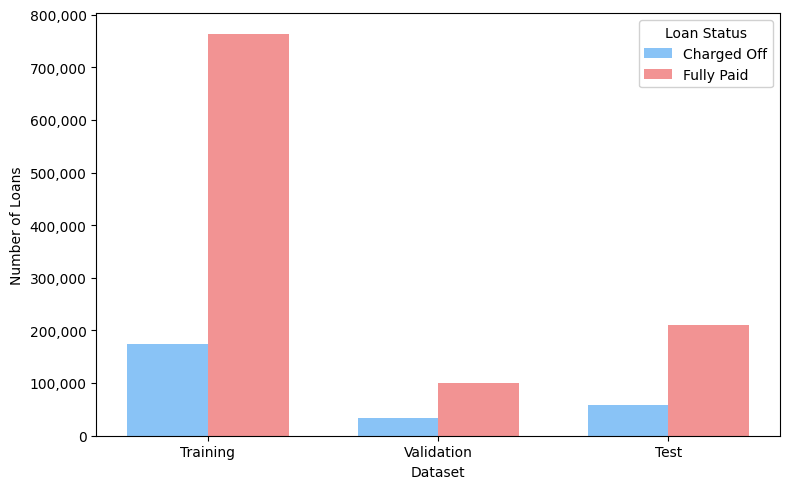

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Contagem de cada classe por base
datasets = {
    'Training': y_train,
    'Validation': y_test,
    'Test': y_test_final
}

charged_off_counts = []
fully_paid_counts = []

for name, y in datasets.items():
    counts = pd.Series(y).value_counts()
    charged_off_counts.append(counts.get(0, 0))
    fully_paid_counts.append(counts.get(1, 0))

# Configuração do gráfico
x = np.arange(len(datasets))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, charged_off_counts, width,
               label='Charged Off', color='#74b9f5', alpha=0.85)
bars2 = ax.bar(x + width/2, fully_paid_counts, width,
               label='Fully Paid', color='#f08080', alpha=0.85)

# Eixos e legendas
ax.set_xlabel('Dataset')
ax.set_ylabel('Number of Loans')
ax.set_xticks(x)
ax.set_xticklabels(datasets.keys())
ax.legend(title='Loan Status', framealpha=0.9)

# Formatação do eixo Y com separador de milhar
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))

plt.tight_layout()
plt.savefig('loan_status_distribution.png', dpi=150)
plt.show()

ROC AUC Score for Model 2: 0.6906
ROC AUC Score for Model 4: 0.6860
ROC AUC Score for Model 5: 0.6920


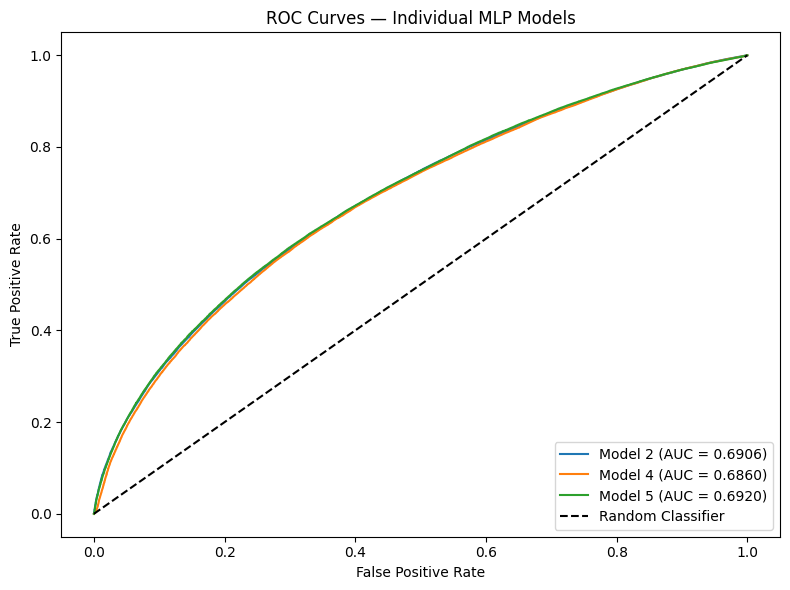

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# AUC scores
# auc_score1 = roc_auc_score(y_test_final, predictions111.flatten())
auc_score2 = roc_auc_score(y_test_final, predictions222.flatten())
# auc_score3 = roc_auc_score(y_test_final, predictions333.flatten())
auc_score4 = roc_auc_score(y_test_final, predictions444.flatten())
auc_score5 = roc_auc_score(y_test_final, predictions555.flatten())


# print(f"ROC AUC Score for Model 1: {auc_score1:.4f}")
print(f"ROC AUC Score for Model 2: {auc_score2:.4f}")
# print(f"ROC AUC Score for Model 3: {auc_score3:.4f}")
print(f"ROC AUC Score for Model 4: {auc_score4:.4f}")
print(f"ROC AUC Score for Model 5: {auc_score5:.4f}")

# ROC Curves
models_info = [
    # (predictions111, auc_score1, 'Model 1'),
    (predictions222, auc_score2, 'Model 2'),
    # (predictions333, auc_score3, 'Model 3'),
    (predictions444, auc_score4, 'Model 4'),
    (predictions555, auc_score5, 'Model 5'),
]

plt.figure(figsize=(8, 6))
for preds, auc, label in models_info:
    fpr, tpr, _ = roc_curve(y_test_final, preds.flatten())
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Individual MLP Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(f"y_train:      {len(y_train):,} amostras")
print(f"y_test:       {len(y_test):,} amostras")
print(f"y_test_final: {len(y_test_final):,} amostras")
print(f"Total:        {len(y_train) + len(y_test) + len(y_test_final):,} amostras")

y_train:      938,718 amostras
y_test:       134,102 amostras
y_test_final: 268,206 amostras
Total:        1,341,026 amostras


In [ ]:
print(len(predictions44))

134102


In [ ]:
from sklearn.metrics import brier_score_loss

# Probabilidades dos modelos individuais
models_probs = {
    # 'Model 1': predictions111.flatten(),
    'Model 2': predictions222.flatten(),
    # 'Model 3': predictions333.flatten(),
    'Model 4': predictions444.flatten(),
    'Model 5': predictions555.flatten()
}

# Probabilidades dos ensembles já calculadas
ensembles_probs = {
    'Scenario 1 (thr=0.5)': final_predictions_s1.flatten(),
    'Scenario 2 (thr=0.5)': final_predictions_s2.flatten(),
    'Scenario 3 (thr=0.8)': final_predictions_s3.flatten(),
    'Scenario 4 (thr=0.8)': final_predictions_s4.flatten(),
}

# Calcular e exibir Brier Scores
print("Brier Score (lower is better):\n")
print("Individual Models:")
for name, probs in models_probs.items():
    bs = brier_score_loss(y_test_final, probs)
    print(f"  {name}: {bs:.6f}")

print("\nEnsemble Scenarios:")
for name, probs in ensembles_probs.items():
    bs = brier_score_loss(y_test_final, probs)
    print(f"  {name}: {bs:.6f}")

Brier Score (lower is better):

Individual Models:
  Model 2: 0.157295
  Model 4: 0.158776
  Model 5: 0.157624

Ensemble Scenarios:
  Scenario 1 (thr=0.5): 0.165153
  Scenario 2 (thr=0.5): 0.164450
  Scenario 3 (thr=0.8): 0.290449
  Scenario 4 (thr=0.8): 0.293828
